<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; "> La Poule qui chante - ANALYSE MARCHE INTERNATIONAL </h1>
</div>

## Objectif 

L'entreprise française d'agroalimentaire "La Poule qui chante" souhaite développer à l'international leur activité d'élevage et de la vente de poulets sous le label "Poulet Agriculture Biologique".

Ce projet a donc pour but d'**analyser le marché international afin d'exporter la production de notre poulet bio à l'échelle international**


**Plan :** 

   Cette étude va commencer par des nettoyage des données et par l'analyse des caractéristiques. Puis, en de ses pays en réduisant leurs dimensions à l'aide de la méthode d'ACP, on va regrouper des pays selon leurs caractéristiques similaires à l'aide de différentes méthodes de clustering (k-means, CAH), afin de déterminer les groupes de pays envisageables pour exporter le produit.

Nous avons sélectionné des variables issues de différentes sources, en cohérence avec l’approche **PESTEL** (Politique, Économique, Social, Technologique, Environnemental et Légal), afin de caractériser les pays étudiés.
Les variables choisies sont les suivantes :

****


**Source :** 

**FAO :**
- Population
- Disponibilité alimentaire (regroupant plusieurs variables)
- Émissions agricoles (CH₄, N₂O)
- Deux indicateurs des ODD (Objectifs de Développement Durable)
- Sécurité alimentaire (regroupant plusieurs variables)
- Inflation des prix alimentaires
- IPP (Indice des Prix à la Production)

**Banque mondiale :**
- Dépenses publiques consacrées aux loisirs, à la culture et à la religion
- Emploi rural
- Paiements d’achats sur Internet

**Datagouv :**
- Code du pays
    
Ce notebook se concentre uniquement sur la première partie de l’étude, à savoir **le nettoyage et la préparation des données**.
La seconde partie, dédiée à l’analyse exploratoire et à la modélisation, est développée dans un autre notebook.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des données </h2>
</div>

### Importation des packages

In [1]:
import sys
print(sys.executable)

C:\Users\cairo\miniconda3\envs\VSprojets\python.exe


In [2]:
# Packages nécessaires
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

### Importation des données

In [3]:
# nom de pays en référence
codepays = pd.read_csv("curiexplore-pays.csv", decimal = ".", sep = ";")[["iso3", "name_en", "name_fr", "iso2"]]

# variables explicatives à traiter
culture_reg = pd.read_csv("CULTE_rec_reg.csv", decimal = ".")
emission = pd.read_csv("FAOSTAT_N2OCH4_elevage.csv", decimal = ".")
emploi_rural = pd.read_csv("FAOSTAT_emploi_rural.csv", decimal = ".")
odd = pd.read_csv("FAOSTAT_indicateurODD.csv", decimal = ".")
wb_payment = pd.read_csv("WB_FINDEX_G20_ANY.csv", decimal = ".")
pop0018 = pd.read_csv("Population_2000_2018.csv", decimal = ".")

dispoAli_2017 = pd.read_csv("DisponibiliteAlimentaire_2017.csv", decimal=".", index_col=0)
secuAli = pd.read_csv("FAOSTAT_santeAli.csv", decimal = ".", index_col=0)
ipp = pd.read_csv("FAOSTAT_ipp_fr.csv", decimal = ".", index_col=0)
foodInfla = pd.read_csv("FAOSTAT_ipc.csv", decimal = ".", index_col=0)


### Fonctions à utiliser

In [4]:
def pivoter_data(data, zone, col_pivot):
    """ Transformer data "longue" en data "courte". Chaque colonne représente une variable et chaque ligne un individu
    """
    # Pivoter les valeurs
    flat_data = data.pivot_table(index = [zone], 
                          columns = col_pivot, 
                          values = ['Valeur']).reset_index()

    # flatten columns
    flat_data.columns = [
        "".join([str(a).strip() for a in col if str(a).strip() not in ("", "nan", "None")])
        for col in flat_data.columns.to_flat_index()
    ]

    return(flat_data)


def correction_zones(zones, new_zones, data):
    """ Remplacer les noms du pays de la data en nouveaux noms
    """
    for old, new in zip(zones, new_zones):
        data.loc[
        data["Zone"].str.contains(old, case=False, na = False), "Zone"] = new




# Fonction corrigeant les outliers
def outliers_median(data, cols):
    """ Détecter les valeurs extrêmes et corriger les outliers par la méthode d'IQR (InterQuartile Range) par leurs propres médianes, sans modifier la distribution des données
    """
    data1 = data.copy()
    for col in cols :
        df = data1[col]
        Q1 = df.quantile(0.10)
        Q3 = df.quantile(0.90)
        IQR = Q3 - Q1

        outliers = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))
    
        print(f"{col} : Le nombre de outliers est {outliers.sum()}. Sa médiane est {round(df.median(),2)}")
    
        data1.loc[outliers, col] = df.median()

    return(data1)


def remplacer_na(data, cols):
    """ Remplacer les valeurs NAs des colonnes choisies d'une dataframe par leurs valeurs centrales
    """
    for col in nomcols:
        mean_val = data[col].mean()
        median_val = data[col].median()
    
        denom = mean_val if mean_val != 0 else 1e-8
        rel_diff = (median_val - mean_val) / denom
    
        if rel_diff <= 0.7 :
            data.loc[:, col] = data[col].fillna(mean_val)
        else :
            data.loc[:, col] = data[col].fillna(median_val)


# Fonctions pour affichages
def plot_logdata(data, cols, nb_row = 1):
    """ Afficher les boxplots des colonnes choisies transformée par la logarithme d'un dataframe sur la même figure
    """
    nb = len(cols)
    fig, ax = plt.subplots(nb_row, nb, figsize=(4 * nb, 4))

    for i in range(nb):
        logcol = np.log1p(data[cols[i]])
        ax[i].boxplot(logcol.dropna())
        ax[i].set_title(f"{cols[i]}", fontsize=10)

    #plt.tight_layout()
    plt.show()
            

def plot_data(data, cols, nb_row = 1):
    """ Afficher les boxplots des colonnes choisies d'un dataframe sur la même figure
    """
    nb = len(cols)
    fig, ax = plt.subplots(nb_row, nb, figsize=(4 * nb, 4))

    for i in range(nb):
        ax[i].boxplot(data[cols[i]].dropna())
        ax[i].set_title(f"{cols[i]}", fontsize=10)

    #plt.tight_layout()
    plt.show()


def hist_data(data, cols, nb_row = 1):
    """ Afficher les histogrammes des colonnes choisies d'un dataframe sur la même figure
    """
    nb = len(cols)
    fig, ax = plt.subplots(nb_row, nb, figsize=(4 * nb, 3))

    for i in range(nb):
        ax[i].hist(data[cols[i]].dropna(), bins = 30)
        ax[i].set_title(f"{cols[i]}")

    #plt.tight_layout()
    plt.show()


def boxhist_data(data, col, nb_row = 1):
    """ Afficher à la fois les histogrammes et à la fois les boxplots de la colonne choisie d'un dataframe sur la même figure
    """
    fig, ax = plt.subplots(nb_row, 2, figsize=(4 * 2, 4))

    ax[0].hist(data[col[0]].dropna(), bins = 50)
    ax[0].set_title(f"Histogramme de {col[0]}")

    ax[1].boxplot(data[col[0]].dropna())
    ax[1].set_title(f"Boxplot de {col[0]}")
    
    #plt.tight_layout()
    plt.show()


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Traitement des données </h2>
</div>

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">0 - Uniformisation des données </h2>
</div>

La première étape avant de réaliser une ACP (Analyse en Composantes Principales) consiste en le prétraitement des données, afin d’uniformiser les différentes bases d’information (noms ou codes d'un pays). 

Ce prétraitement porte notamment sur :
- l’harmonisation des noms des pays ;
- la conversion des variables en données numériques, indispensable à la réalisation de l’ACP ;
- le traitement des valeurs manquantes, afin d’obtenir une matrice exploitable.

On commence par étudier les variables individuellement, afin de vérifier la bonne harmonisation des noms des pays avant la jointure des bases de données. On procéde ensuite au nettoyage des données, notamment le traitement des valeurs manquantes et des valeurs extrêmes.


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - Code de pays </h3>
</div>

Source : https://www.data.gouv.fr/datasets/liste-des-pays-et-territoires/

Nous utiliserons les informations du fichier « Code_pays » comme référentiel pour les noms des pays étudiés.

In [5]:
codepays.info()
codepays.sort_values(by="name_en").head()
# 216 pays au total

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   iso3     216 non-null    object
 1   name_en  216 non-null    object
 2   name_fr  216 non-null    object
 3   iso2     214 non-null    object
dtypes: object(4)
memory usage: 6.9+ KB


,iso3,name_en,name_fr,iso2
12,AFG,Afghanistan,Afghanistan,AF
129,ALB,Albania,Albanie,AL
14,DZA,Algeria,Algérie,DZ
19,ASM,American Samoa,Samoa américaines,AS
162,AND,Andorra,Andorre,AD


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - Dépenses publiques pour les loisirs, la culture et la religion </h3>
</div>

Une caractéristique à caractère culturelle et sociale retenue est le pourcentage de dépense totale par rapport au monnaie sur la récréation, culture et la religion.

**Source :** https://data360.worldbank.org/en/indicator/WB_BOOST_EXP_FUNC_REV_CUS_EXC?view=trend

In [6]:
culture_reg.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,WB_BOOST_EXP_FUNC_REV_CUS_EXC,"Recreation, culture and religion (COFOG 708)",_T,...,0,Units,CUR,Currency,602,CCYY,O,Missing value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,WB_BOOST_EXP_FUNC_REV_CUS_EXC,"Recreation, culture and religion (COFOG 708)",_T,...,0,Units,CUR,Currency,602,CCYY,O,Missing value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,WB_BOOST_EXP_FUNC_REV_CUS_EXC,"Recreation, culture and religion (COFOG 708)",_T,...,0,Units,CUR,Currency,602,CCYY,O,Missing value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARG,Argentina,WB_BOOST_EXP_FUNC_REV_CUS_EXC,"Recreation, culture and religion (COFOG 708)",_T,...,0,Units,CUR,Currency,602,CCYY,O,Missing value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARM,Armenia,WB_BOOST_EXP_FUNC_REV_CUS_EXC,"Recreation, culture and religion (COFOG 708)",_T,...,0,Units,CUR,Currency,602,CCYY,A,Normal value,PU,Public


In [7]:
culture_reg1 = culture_reg.loc[(culture_reg["TIME_PERIOD"]==2017) & (culture_reg["UNIT_MEASURE"]=="PT_EXP") & (culture_reg["COMP_BREAKDOWN_1"]=="WB_BOOST_BUDGET_PARAM_2")].reset_index()
culture_reg1 = culture_reg1[["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE"]]
culture_reg1.info()
culture_reg1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   REF_AREA        155 non-null    object 
 1   REF_AREA_LABEL  155 non-null    object 
 2   TIME_PERIOD     155 non-null    int64  
 3   OBS_VALUE       127 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 5.0+ KB


,REF_AREA,REF_AREA_LABEL,TIME_PERIOD,OBS_VALUE
0,AFG,Afghanistan,2017,1.011897
1,ALB,Albania,2017,1.395815
2,AGO,Angola,2017,0.867927
3,ARG,Argentina,2017,NaN
4,ARM,Armenia,2017,2.179371


In [8]:
# Changement de nom
culture_reg1.loc[culture_reg1["REF_AREA"]=="XKX", "REF_AREA"] = "KOS"

### Jointure avec pays

Faire un test de jointure pour s'assurer une bonne jointure.

In [9]:
pays_culture = pd.merge(codepays, culture_reg1, how = "outer", left_on = "iso3", right_on = "REF_AREA", indicator=True).reset_index(drop=True)
print(pays_culture.info())

# Vérifier si jointure match exactement
pays_culture.loc[pays_culture["_merge"]=="right_only"] # ne pas les prendre en compte


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   iso3            216 non-null    object  
 1   name_en         216 non-null    object  
 2   name_fr         216 non-null    object  
 3   iso2            214 non-null    object  
 4   REF_AREA        155 non-null    object  
 5   REF_AREA_LABEL  155 non-null    object  
 6   TIME_PERIOD     155 non-null    float64 
 7   OBS_VALUE       127 non-null    float64 
 8   _merge          217 non-null    category
dtypes: category(1), float64(2), object(6)
memory usage: 14.0+ KB
None


,iso3,name_en,name_fr,iso2,REF_AREA,REF_AREA_LABEL,TIME_PERIOD,OBS_VALUE,_merge
41,NaN,NaN,NaN,NaN,COK,Cook Islands,2017.0,1.033173,right_only


In [10]:
codepays.loc[codepays["name_fr"].str.contains("co", case = False, na = False)]
# Il n'existe pas ile de cook du côté codepays. On ne va pas le prendre en compte

,iso3,name_en,name_fr,iso2
21,COD,Congo (Democratic Republic of the),Congo (Rép. dém.),CD
98,KOR,Korea (Republic of),Corée du Sud,KR
108,COG,Congo,Congo,CG
114,PRI,Puerto Rico,Porto Rico,PR
123,COM,Comoros,Comores,KM
127,PRK,Korea (Democratic Peoples Republic of),Corée du Nord,KP
152,CRI,Costa Rica,Costa Rica,CR
194,COL,Colombia,Colombie,CO
210,MCO,Monaco,Monaco,MC


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - Emissions (CH4, N2O) éputable à l'élevage de poulet à viande </h3>
</div>


Les émissions de CH₄ et de N₂O constituent les caractéristiques environnementales retenues. On s'intéresse uniquement à ces émissions dans la catégorie de « poulets à viande ».

Source : https://www.fao.org/faostat/fr/#data/GT

In [11]:
emission1 = emission[emission["Produit"] == "Poulets à viande"].reset_index()
emission1 = emission1[["Zone", "Année", "Élément", "Valeur"]]

emission1.info()
emission1.head()  # nécessite de retraitement pivot

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Zone     588 non-null    object 
 1   Année    588 non-null    int64  
 2   Élément  588 non-null    object 
 3   Valeur   588 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 18.5+ KB


,Zone,Année,Élément,Valeur
0,Afghanistan,2017,Réserves,2.885000e+06
1,Afghanistan,2017,Total imputable à l'élevage (émissions N2O),3.480000e-02
2,Afghanistan,2017,Total imputable à l'élevage (émissions CH4),2.890000e-02
3,Afrique du Sud,2017,Réserves,1.290330e+08
4,Afrique du Sud,2017,Total imputable à l'élevage (émissions N2O),1.707200e+00


In [12]:
emission_flat = pivoter_data(emission1, "Zone", "Élément")
emission_flat.info() # 196 pays et valeurs non vides

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 4 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Zone                                               196 non-null    object 
 1   ValeurRéserves                                     196 non-null    float64
 2   ValeurTotal imputable à l'élevage (émissions CH4)  196 non-null    float64
 3   ValeurTotal imputable à l'élevage (émissions N2O)  196 non-null    float64
dtypes: float64(3), object(1)
memory usage: 6.3+ KB


In [13]:
emission_flat.describe()
# Les valeurs sont très assymétriques => une transformation en log peut être nécessaire. 
# Valeurs positives & possède des valeurs extrêmes

,ValeurRéserves,ValeurTotal imputable à l'élevage (émissions CH4),ValeurTotal imputable à l'élevage (émissions N2O)
count,1.960000e+02,196.000000,196.000000
mean,9.954910e+07,1.743295,1.195545
std,3.474171e+08,5.891384,4.171428
min,0.000000e+00,0.000000,0.000000
25%,2.433750e+06,0.039225,0.030050
50%,1.479000e+07,0.291050,0.185700
75%,5.544550e+07,0.941725,0.671875
max,3.222337e+09,64.446700,38.898900


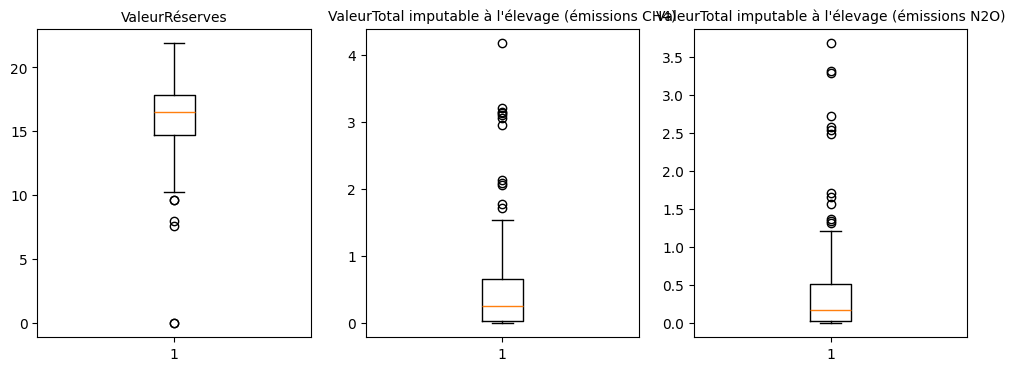

In [14]:
plot_logdata(emission_flat, emission_flat.columns[1:].tolist())
# La transformation logarithmique des variables de distribution assymétrique 

### Jointure avec pays

In [15]:
# corrige les noms de pays
zones = ["Arabie saoudite", "Bolivie", "Chine - RAS de Hong-Kong", "Chine - RAS de Macao", "Bélarus", 
        "Fédération de Russie", "Iran", "Iraq", "Guinée équatoriale", "Libéria", "Micronesie", "Ouganda", "Palestine", 
         "Etat-Unis", "République de Corée", "République populaire démocratique de Corée", "populaire lao",
        "République démocratique du Congo", "République arabe syrienne", "République-Unie de Tanzanie", 
        "Saint-Vincent-et-les Grenadines", "Tchéquie", "Trinité-et-Tobago", "Türkiye","Venezuela", "Viet Nam", 
        "Égypte", "Émirats arabes unis", "Érythrée", "Éthiopie", "Maurice", "Côte d'Ivoire", 
        "Cabo Verde", "El Salvador", "Moldova", "États-Unis", "Taiwan", "équateur", "Royaume-Uni"]

zones_remp = ["Arabie Saoudite", "Bolivie", "Hong Kong (Chine)", "Macao (Chine)", "Biélorussie", 
             "Russie", "Iran", "Irak", "Guinée-Équatoriale", "Liberia", "Micronesie", "Uganda", "Territoires palestiniens",
              "Etat-Unis", "Corée du Nord", "Corée du Sud", "Laos",
              "Congo (Rép. dém.)", "Syrie", "Tanzanie",
             "Saint-Vincent-et-les-Grenadines", "République tchèque", "Trinité et Tobago", "Turquie", "Venezuela", "Viêt Nam", 
             "Egypte", "Emirats arabes unis", "Erythrée", "Ethiopie", "Ile Maurice", "Côte dIvoire", 
             "Cap Vert", "Salvador", "Moldavie", "Etats-Unis", "Taïwan", "Equateur", "Royaume-Unis"]


# transformation des noms
correction_zones(zones, zones_remp, emission_flat)

In [16]:
emission_flat.loc[emission_flat.duplicated("Zone")]  # Pas de duplication

,Zone,ValeurRéserves,ValeurTotal imputable à l'élevage (émissions CH4),ValeurTotal imputable à l'élevage (émissions N2O)


In [17]:
pays_emission = pd.merge(codepays, emission_flat, how = "outer", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_emission.loc[pays_emission["_merge"]=="right_only"].head()
# Ces infos sont en "trop"

,iso3,name_en,name_fr,iso2,Zone,ValeurRéserves,ValeurTotal imputable à l'élevage (émissions CH4),ValeurTotal imputable à l'élevage (émissions N2O),_merge
29,NaN,NaN,NaN,NaN,Brunéi Darussalam,1.603300e+07,0.3207,0.1935,right_only
41,NaN,NaN,NaN,NaN,"Chine, continentale",2.142945e+09,21.4294,25.8688,right_only
126,NaN,NaN,NaN,NaN,Micronésie (États fédérés de),9.800000e+04,0.0020,0.0011,right_only
132,NaN,NaN,NaN,NaN,Myanmar,2.459340e+08,4.9187,2.9688,right_only
138,NaN,NaN,NaN,NaN,Nioué,1.500000e+04,0.0003,0.0002,right_only


In [18]:
# Vérifier les informations sont bien intégrées pour certains pays
pays_emission.loc[pays_emission["name_fr"].str.contains("chine", case=False, na=False)]


,iso3,name_en,name_fr,iso2,Zone,ValeurRéserves,ValeurTotal imputable à l'élevage (émissions CH4),ValeurTotal imputable à l'élevage (émissions N2O),_merge
40,CHN,China,Chine,CN,Chine,2.202739e+09,22.6253,26.5907,both
85,HKG,Hong Kong,Hong Kong (Chine),HK,Hong Kong (Chine),4.133000e+06,0.0827,0.0499,both
114,MAC,Macao,Macao (Chine),MO,Macao (Chine),6.600000e+05,0.0132,0.0080,both


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - Emploi rural </h3>
</div>

Le nombre d’emplois en milieu rural occupés par des personnes âgées de plus de 15 ans (en milliers) reflète indirectement l'économie du secteur agricole, en tant qu'une variable à la fois économique et à la fois sociale.

**Source :** https://www.fao.org/faostat/fr/#data/OER

In [19]:
emploi_rural.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code indicateur,Indicateur,Code sexe,Sexe,Code année,Année,Code Élément,Élément,Code source,Source,Unité,Valeur,Symbole,Description du Symbole,Note
0,OER,Indicateurs de l’emploi: milieu rural,710,Afrique du Sud,21087,"Employment by age, total (15+), rural areas",1,Total,2017,2017,6199,Valeur,3023,Labour force survey,1000 No,3861.34,X,Chiffre de source externe,Repository: ILO-STATISTICS - Micro data proces...
1,OER,Indicateurs de l’emploi: milieu rural,12,Algérie,21087,"Employment by age, total (15+), rural areas",1,Total,2017,2017,6199,Valeur,3023,Labour force survey,1000 No,3728.89,X,Chiffre de source externe,Data reference period: September
2,OER,Indicateurs de l’emploi: milieu rural,276,Allemagne,21087,"Employment by age, total (15+), rural areas",1,Total,2017,2017,6199,Valeur,3023,Labour force survey,1000 No,9617.58,X,Chiffre de source externe,Repository: ILO-STATISTICS - Micro data proces...
3,OER,Indicateurs de l’emploi: milieu rural,51,Arménie,21087,"Employment by age, total (15+), rural areas",1,Total,2017,2017,6199,Valeur,3023,Labour force survey,1000 No,481.01,X,Chiffre de source externe,Repository: ILO-STATISTICS - Micro data proces...
4,OER,Indicateurs de l’emploi: milieu rural,36,Australie,21087,"Employment by age, total (15+), rural areas",1,Total,2017,2017,6199,Valeur,3023,Labour force survey,1000 No,3877.64,X,Chiffre de source externe,Working time arrangement coverage: Full-time a...


In [20]:
emploi_rural1 = emploi_rural.copy()
emploi_rural1 = emploi_rural1[["Zone", "Valeur"]]

emploi_rural1.info()
emploi_rural1.head(5) # 104 non nul

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    104 non-null    object 
 1   Valeur  104 non-null    float64
dtypes: float64(1), object(1)
memory usage: 1.8+ KB


,Zone,Valeur
0,Afrique du Sud,3861.34
1,Algérie,3728.89
2,Allemagne,9617.58
3,Arménie,481.01
4,Australie,3877.64


In [21]:
emploi_rural1.describe() # valeur est positive mais très assymétrique

,Valeur
count,104.000000
mean,10755.963846
std,45546.576583
min,6.970000
25%,561.612500
50%,1482.800000
75%,4692.437500
max,328500.000000


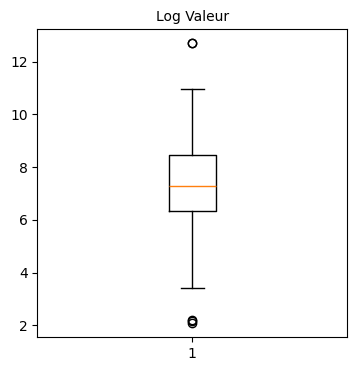

In [22]:
plt.subplots(1, 1, figsize=(4 , 4))
plt.boxplot(np.log1p(emploi_rural1["Valeur"].dropna()))
plt.title(f"Log {emploi_rural1.columns[1]}", fontsize = 10)
plt.show()
# réduction d'anomalies avec log

### Jointure avec pays

In [23]:
# Corrige les noms de pays
zones = ["Arabie saoudite", "Bolivie ", "Chine - RAS de Hong-Kong", "Chine - RAS de Macao", "Bélarus", 
        "Fédération de Russie", "Iran ", "Guinée équatoriale", "Libéria", "Micronesie", "Ouganda", "Palestine", 
        "Royaume-Uni", "États-Unis", "République de Corée", "République populaire démocratique de Corée", 
        "République démocratique du Congo", "Lao", "République arabe syrienne", "République-Unie de Tanzanie", 
        "Saint-Vincent-et-les Grenadines", "Tchéquie", "Trinité-et-Tobago", "Türkiye","Venezuela", "Viet Nam", 
        "Égypte", "Émirats arabes unis", "Érythrée", "Éthiopie", "Maurice", "Iraq", "Pays-Bas ", "Équateur", "Côte d'Ivoire", 
        "El Salvador", "Cabo Verde", "de Moldova"]

zones_remp = ["Arabie Saoudite", "Bolivie", "Hong Kong (Chine)", "Macao (Chine)", "Biélorussie", 
             "Russie", "Iran", "Guinée-Équatoriale", "Liberia", "Micronesie", "Uganda", "Territoires palestiniens",
             "Royaume-Uni", "Etats-Unis", "Corée du Nord", "Corée du Sud", 
              "Congo (Rép. dém.)", "Laos", "Syrie", "Tanzanie",
             "Saint-Vincent-et-les-Grenadines", "République tchèque", "Trinité et Tobago", "Turquie", "Venezuela", "Viêt Nam", 
             "Egypte", "Emirats arabes unis", "Erythrée", "Ile Maurice", "Irak", "Pays-Bas", "Equateur", "Côte dIvoire", 
             "Salvador", "Cap Vert", "Moldavie"]


correction_zones(zones, zones_remp, emploi_rural1)


In [24]:
emploi_rural1.loc[emploi_rural1.duplicated("Zone")] # Pas duplication

,Zone,Valeur


In [25]:
pays_emploi = pd.merge(codepays, emploi_rural1, how = "outer", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_emploi.loc[pays_emploi["_merge"]=="right_only"] # non correspondance, ou en duplication

,iso3,name_en,name_fr,iso2,Zone,Valeur,_merge
29,NaN,NaN,NaN,NaN,Brunéi Darussalam,44.52,right_only
41,NaN,NaN,NaN,NaN,"Chine, continentale",328500.00,right_only
159,NaN,NaN,NaN,NaN,République de Moldova,1044.45,right_only


In [26]:
pays_emploi.loc[pays_emploi["name_fr"].str.contains("chine", case=False, na=False)] # Etat-unis existe toujours tout comme chine

,iso3,name_en,name_fr,iso2,Zone,Valeur,_merge
40,CHN,China,Chine,CN,Chine,328500.0,both
85,HKG,Hong Kong,Hong Kong (Chine),HK,NaN,NaN,left_only
114,MAC,Macao,Macao (Chine),MO,NaN,NaN,left_only


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - Indicateur ODD </h3>
</div>

Deux indicateurs ODD (Objectifs de développement durable) permettant d’évaluer la sécurité alimentaire d’un pays sont utilisés :
- Nombre de personnes sous-alimentées (Number of undernourished people)
- Efficacité d’utilisation de l’eau en agriculture (Water Use Efficiency – Agriculture (ISIC4 A01, A0210, A0322))


Ce sont des caractéristiques de santé, technologique et écologique.

**Source :** https://www.fao.org/faostat/fr/#data/SDGB

In [27]:
odd.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit (SDG),Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,SDGB,Indicateurs ODD,4,Afghanistan,6132,Valeur,SN_ITK_DEFCN,2.1.1 Number of undernourished people,2017,2017,millions de No,7.6,E,Valeur estimée,Estimated | Food and Agriculture Organization ...
1,SDGB,Indicateurs ODD,4,Afghanistan,6178,Valeur,ER_H2O_WUEYST_AGR,6.4.1 Water Use Efficiency (Agriculture (ISIC4...,2017,2017,USD/m3,0.11,A,Chiffre officiel,Global monitoring data | Food and Agriculture ...
2,SDGB,Indicateurs ODD,4,Afghanistan,6178,Valeur,ER_H2O_WUEYST_IND,6.4.1 Water Use Efficiency (Industries),2017,2017,USD/m3,10.29,A,Chiffre officiel,Global monitoring data | Food and Agriculture ...
3,SDGB,Indicateurs ODD,4,Afghanistan,6178,Valeur,ER_H2O_WUEYST_SER,6.4.1 Water Use Efficiency (Services (G to T)),2017,2017,USD/m3,58.17,A,Chiffre officiel,Global monitoring data | Food and Agriculture ...
4,SDGB,Indicateurs ODD,4,Afghanistan,6178,Valeur,ER_H2O_WUEYST_TOT,6.4.1 Water Use Efficiency (No breakdown),2017,2017,USD/m3,0.77,A,Chiffre officiel,Global monitoring data | Food and Agriculture ...


In [28]:
odd1 = odd.copy()

odd1 = odd1.loc[(odd["Produit"]=="2.1.1 Number of undernourished people") | (odd["Produit"]=="6.4.1 Water Use Efficiency (Agriculture (ISIC4 A01 A0210 A0322))")].reset_index()
odd1 = odd1[["Zone", "Produit", "Valeur"]]
odd1["Valeur"] = pd.to_numeric(odd1["Valeur"], errors="coerce")

In [29]:
odd_flat = pivoter_data(odd1, "Zone", "Produit")
odd_flat.info() #202 non nul
odd_flat.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 3 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   Zone                                                                    217 non-null    object 
 1   Valeur2.1.1 Number of undernourished people                             127 non-null    float64
 2   Valeur6.4.1 Water Use Efficiency (Agriculture (ISIC4 A01 A0210 A0322))  202 non-null    float64
dtypes: float64(2), object(1)
memory usage: 5.2+ KB


,Zone,Valeur2.1.1 Number of undernourished people,Valeur6.4.1 Water Use Efficiency (Agriculture (ISIC4 A01 A0210 A0322))
0,Afghanistan,7.6,0.11
1,Afrique,210.3,NaN
2,Afrique australe,4.7,NaN
3,Afrique centrale,41.5,NaN
4,Afrique du Sud,3.5,0.15


In [30]:
odd_flat.describe() # valeurs sont tous positives et très assymétrique

,Valeur2.1.1 Number of undernourished people,Valeur6.4.1 Water Use Efficiency (Agriculture (ISIC4 A01 A0210 A0322))
count,127.00000,202.000000
mean,28.96063,0.901089
std,74.35200,2.289704
min,0.10000,0.000000
25%,1.00000,0.142500
50%,2.80000,0.310000
75%,12.45000,0.710000
max,546.10000,26.700000


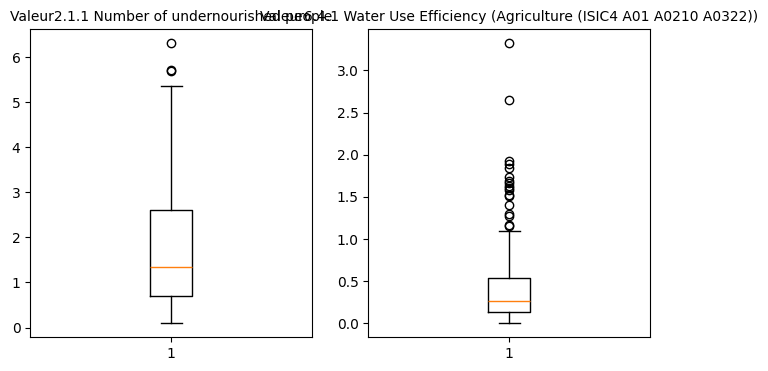

In [31]:
plot_logdata(odd_flat, odd_flat.columns[1:].to_list()) # en valeurs logarithmiques

### Jointure avec pays

In [32]:
# corrige les noms 
zones = ["Arabie saoudite", "Bolivie ", "Chine - RAS de Hong-Kong", "Chine - RAS de Macao", "Bélarus", 
        "Fédération de Russie", "Iran ", "Guinée équatoriale", "Libéria", "Micronesie", "Ouganda", "Palestine", 
        "Royaume-Uni", "République de Corée", "République populaire démocratique de Corée", 
        "République démocratique du Congo", "Lao", "République arabe syrienne", "République-Unie de Tanzanie", 
        "Saint-Vincent-et-les Grenadines", "Tchéquie", "Trinité-et-Tobago", "Türkiye","Venezuela", "Viet Nam", 
        "Égypte", "Émirats arabes unis", "Érythrée", "Éthiopie", "Maurice", "Iraq", "Pays-Bas ", "Équateur", "Côte d'Ivoire", 
        "El Salvador", "Cabo Verde", "de Moldova", "Chine, Taiwan Province de", "Chine, continentale", "États-Unis d'Amérique"]

zones_remp = ["Arabie Saoudite", "Bolivie", "Hong Kong (Chine)", "Macao (Chine)", "Biélorussie", 
             "Russie", "Iran", "Guinée-Équatoriale", "Liberia", "Micronesie", "Uganda", "Territoires palestiniens",
             "Royaume-Uni", "Corée du Nord", "Corée du Sud", 
              "Congo (Rép. dém.)", "Laos", "Syrie", "Tanzanie",
             "Saint-Vincent-et-les-Grenadines", "République tchèque", "Trinité et Tobago", "Turquie", "Venezuela", "Viêt Nam", 
             "Egypte", "Emirats arabes unis", "Erythrée", "Éthiopie", "Ile Maurice", "Irak", "Pays-Bas", "Equateur", "Côte dIvoire", 
             "Salvador", "Cap Vert", "Moldavie", "Taïwan", "Chine", "Etats-Unis"]


correction_zones(zones, zones_remp, odd_flat)


In [33]:
odd_flat.loc[odd_flat.duplicated("Zone")] # Pas duplication

,Zone,Valeur2.1.1 Number of undernourished people,Valeur6.4.1 Water Use Efficiency (Agriculture (ISIC4 A01 A0210 A0322))


In [34]:
pays_odd = pd.merge(codepays, odd_flat, how = "outer", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_odd.loc[pays_odd["_merge"]=="right_only"].head() # infos par régions, pas utile

,iso3,name_en,name_fr,iso2,Zone,Valeur2.1.1 Number of undernourished people,Valeur6.4.1 Water Use Efficiency (Agriculture (ISIC4 A01 A0210 A0322)),_merge
1,NaN,NaN,NaN,NaN,Afrique,210.3,NaN,right_only
2,NaN,NaN,NaN,NaN,Afrique australe,4.7,NaN,right_only
3,NaN,NaN,NaN,NaN,Afrique centrale,41.5,NaN,right_only
5,NaN,NaN,NaN,NaN,Afrique occidentale,44.0,NaN,right_only
6,NaN,NaN,NaN,NaN,Afrique orientale,105.1,NaN,right_only


In [35]:
pays_odd.loc[pays_odd["name_fr"].str.contains("unis", case = False, na = False)].head() # infos bien intégré

,iso3,name_en,name_fr,iso2,Zone,Valeur2.1.1 Number of undernourished people,Valeur6.4.1 Water Use Efficiency (Agriculture (ISIC4 A01 A0210 A0322)),_merge
81,ARE,United Arab Emirates,Emirats arabes unis,AE,Emirats arabes unis,0.3,1.27,both
87,USA,United States of America,Etats-Unis,US,Etats-Unis,NaN,0.21,both
237,TUN,Tunisia,Tunisie,TN,Tunisie,0.3,0.28,both


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - Payment d'achat en ligne </h3>
</div>

Le caractéristique du paiement d'une commande en ligne (Pourcentage des jeunes de 15 à 24 ans déclarée avoir effectué un achat via un compte bancaire ou un compte de monnaie mobile en ligne) reflète l'avancée et l'utilisation quotidienne des technologies informatiques. On a donc choisi cette variable.

**Source :** https://data360.worldbank.org/en/indicator/WB_FINDEX_G20_ANY

In [36]:
wb_payment.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,UNIT_TYPE_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,DATA_SOURCE_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,MAR,WB_FINDEX_G20_ANY,_T,Y_GE25,_T,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,MAR,WB_FINDEX_G20_ANY,_T,Y15T24,_T,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,MOZ,WB_FINDEX_G20_ANY,_T,Y_GE25,_T,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,MOZ,WB_FINDEX_G20_ANY,_T,Y15T24,_T,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A3,MMR,WB_FINDEX_G20_ANY,_T,Y_GE25,_T,PT_RESP,...,Total,Total,Total,Ratio,Global Findex Database,CCYY,Units,Normal value,Global Findex Database,Public


In [37]:
wb_payment1 = wb_payment.loc[(wb_payment["SEX"]=="_T") & (wb_payment["AGE"] == "Y15T24") & 
                             (wb_payment["URBANISATION"] == "_T") & (wb_payment["COMP_BREAKDOWN_1"] == "_T") &
                            (wb_payment["COMP_BREAKDOWN_2"] == "_T") & (wb_payment["COMP_BREAKDOWN_3"] == "_T") & 
                            (wb_payment["TIME_PERIOD"] == 2017)].reset_index(drop=True)

wb_payment1 = wb_payment1[["TIME_PERIOD", "REF_AREA", "OBS_VALUE", "REF_AREA_LABEL"]]

wb_payment1.info() # 152 non nuls
wb_payment1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TIME_PERIOD     152 non-null    int64  
 1   REF_AREA        152 non-null    object 
 2   OBS_VALUE       152 non-null    float64
 3   REF_AREA_LABEL  152 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 4.9+ KB


,TIME_PERIOD,REF_AREA,OBS_VALUE,REF_AREA_LABEL
0,2017,LMY,36.186271,Low & middle income
1,2017,EAP,60.121001,East Asia & Pacific (excluding high income)
2,2017,ECA,38.318455,Europe & Central Asia (excluding high income)
3,2017,SSA,29.996600,Sub-Saharan Africa (excluding high income)
4,2017,LAC,33.228296,Latin America & Caribbean (excluding high income)


In [38]:
wb_payment1.loc[wb_payment1.duplicated("REF_AREA")] # Pas de duplication

,TIME_PERIOD,REF_AREA,OBS_VALUE,REF_AREA_LABEL


In [39]:
wb_payment1.describe()  # valeur positive et assez symétrique

,TIME_PERIOD,OBS_VALUE
count,152.0,152.000000
mean,2017.0,44.479367
std,0.0,25.459342
min,2017.0,6.200051
25%,2017.0,24.694115
50%,2017.0,36.786886
75%,2017.0,62.108893
max,2017.0,100.000000


### Jointure avec pays

In [40]:
pays_payment = pd.merge(codepays, wb_payment1, how = "outer", left_on = "iso3", right_on = "REF_AREA", indicator=True).reset_index(drop=True)
pays_payment.loc[pays_payment["_merge"]=="right_only"].head() # Pas utile

,iso3,name_en,name_fr,iso2,TIME_PERIOD,REF_AREA,OBS_VALUE,REF_AREA_LABEL,_merge
56,NaN,NaN,NaN,NaN,2017.0,EAP,60.121001,East Asia & Pacific (excluding high income),right_only
57,NaN,NaN,NaN,NaN,2017.0,ECA,38.318455,Europe & Central Asia (excluding high income),right_only
110,NaN,NaN,NaN,NaN,2017.0,LAC,33.228296,Latin America & Caribbean (excluding high income),right_only
116,NaN,NaN,NaN,NaN,2017.0,LIC,22.017003,Low income,right_only
119,NaN,NaN,NaN,NaN,2017.0,LMC,25.466992,Lower middle income,right_only


In [41]:
pays_payment.loc[pays_payment["name_fr"].str.contains("unis", case = False, na = False)].head() # bien macther

,iso3,name_en,name_fr,iso2,TIME_PERIOD,REF_AREA,OBS_VALUE,REF_AREA_LABEL,_merge
5,ARE,United Arab Emirates,Emirats arabes unis,AE,2017.0,ARE,52.593337,United Arab Emirates,both
204,TUN,Tunisia,Tunisie,TN,2017.0,TUN,15.557793,Tunisia,both
213,USA,United States of America,Etats-Unis,US,2017.0,USA,84.725121,United States,both


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - Population </h3>
</div>

In [42]:
pop17 = pop0018.loc[pop0018["Année"]== 2017].reset_index(drop=True)
pop17 = pop17[["Zone", "Valeur"]]

pop17.info()
pop17.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    236 non-null    object 
 1   Valeur  236 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.8+ KB


,Zone,Valeur
0,Afghanistan,36296.113
1,Afrique du Sud,57009.756
2,Albanie,2884.169
3,Algérie,41389.189
4,Allemagne,82658.409


In [43]:
pop17.describe() # valeurs positives et très assymétrique

,Valeur
count,2.360000e+02
mean,3.198362e+04
std,1.318949e+05
min,7.930000e-01
25%,3.803032e+02
50%,5.203511e+03
75%,1.930842e+04
max,1.421022e+06


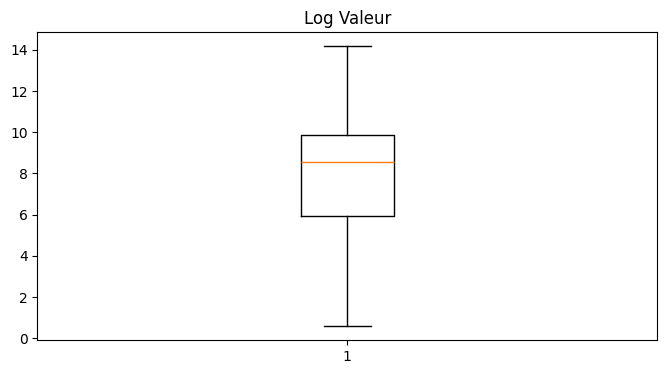

In [44]:
plt.subplots(1, 1, figsize = (8, 4))
plt.boxplot(np.log1p(pop17["Valeur"]))
plt.title(f"Log {pop17.columns[1]}")
plt.show() # la distribution est plus interprétable et symétrique

### Jointure avec pays

In [45]:
zones = ["Arabie saoudite", "Bolivie ", "Chine - RAS de Hong-Kong", "Chine - RAS de Macao", "Bélarus", 
        "Fédération de Russie", "Iran ", "Guinée équatoriale", "Libéria", "Micronésie ", "Ouganda", "Palestine", 
        "République de Corée", "République populaire démocratique de Corée", 
        "République démocratique du Congo", "République arabe syrienne", "République-Unie de Tanzanie", 
        "Saint-Vincent-et-les Grenadines", "Tchéquie", "Trinité-et-Tobago", "Türkiye","Venezuela", "Viet Nam", 
        "Égypte", "Émirats arabes unis", "Érythrée", "Éthiopie", "Maurice", 
        "Cabo Verde", "de Moldova", "Chine, continentale", "États-Unis", "Chine, Taiwan Province de"]

zones_remp = ["Arabie Saoudite", "Bolivie", "Hong Kong (Chine)", "Macao (Chine)", "Biélorussie", 
             "Russie", "Iran", "Guinée-Équatoriale", "Liberia", "Micronesie", "Uganda", "Territoires palestiniens",
             "Corée du Nord", "Corée du Sud", 
              "Congo (Rép. dém.)", "Syrie", "Tanzanie",
             "Saint-Vincent-et-les-Grenadines", "République tchèque", "Trinité et Tobago", "Turquie", "Venezuela", "Viêt Nam", 
             "Egypte", "Emirats arabes unis", "Erythrée", "Ethiopie", "Ile Maurice", 
              "Cap Vert", "Moldavie", "Chine", "Etats-Unis", "Taïwan"]


correction_zones(zones, zones_remp, pop17)

In [46]:
pop17.loc[pop17.duplicated("Zone")] # non duplication

,Zone,Valeur


In [47]:
pays_pop = pd.merge(codepays, pop17, how = "outer", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_pop.loc[pays_pop["_merge"]== "right_only"].head() # Pas important, on peut ne pas les prendre en compte

,iso3,name_en,name_fr,iso2,Zone,Valeur,_merge
7,NaN,NaN,NaN,NaN,Anguilla,14.584,right_only
9,NaN,NaN,NaN,NaN,Antilles néerlandaises (ex),275.186,right_only
28,NaN,NaN,NaN,NaN,"Bonaire, Saint-Eustache et Saba",25.401,right_only
32,NaN,NaN,NaN,NaN,Brunéi Darussalam,424.473,right_only
55,NaN,NaN,NaN,NaN,Côte d'Ivoire,24437.470,right_only


In [48]:
pays_pop.loc[pays_pop["name_fr"].str.contains("unis", case = False, na = False)].head() # bien intégré

,iso3,name_en,name_fr,iso2,Zone,Valeur,_merge
62,ARE,United Arab Emirates,Emirats arabes unis,AE,Emirats arabes unis,9487.203,both
68,USA,United States of America,Etats-Unis,US,Etats-Unis,325084.756,both
223,TUN,Tunisia,Tunisie,TN,Tunisie,11433.443,both


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - Disponibilité alimentaire en 2017 </h3>
</div>

Les données de disponibilité alimentaire contiennent beaucoup d'éléments provenant de la source FAO, mais on s'intéresse uniquement au produit de "Viande de Volailles". 

Ce sont des données indiquent la situation d'économie et de santé d'un pays.

In [49]:
dispoAli_2017.info()
dispoAli_2017.head()

<class 'pandas.core.frame.DataFrame'>
Index: 176600 entries, FBS to FBS
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Domaine                 176600 non-null  object 
 1   Code zone               176600 non-null  int64  
 2   Zone                    176600 non-null  object 
 3   Code Élément            176600 non-null  int64  
 4   Élément                 176600 non-null  object 
 5   Code Produit            176600 non-null  int64  
 6   Produit                 176600 non-null  object 
 7   Code année              176600 non-null  int64  
 8   Année                   176600 non-null  int64  
 9   Unité                   176600 non-null  object 
 10  Valeur                  176600 non-null  float64
 11  Symbole                 176600 non-null  object 
 12  Description du Symbole  176600 non-null  object 
dtypes: float64(1), int64(5), object(7)
memory usage: 18.9+ MB


,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
Code Domaine,,,,,,,,,,,,,
FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées
FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.0,S,Données standardisées


In [50]:
# Catégorie de la colonne 
dispoAli_2017["Élément"].value_counts() # à pivoter 

Élément
Disponibilité intérieure                                         15905
Importations - Quantité                                          15260
Disponibilité alimentaire en quantité (kg/personne/an)           14618
Disponibilité de matière grasse en quantité (g/personne/jour)    14512
Disponibilité de protéines en quantité (g/personne/jour)         14507
Nourriture                                                       14498
Disponibilité alimentaire (Kcal/personne/jour)                   14476
Résidus                                                          12567
Exportations - Quantité                                          12113
Variation de stock                                               11299
Production                                                       10334
Pertes                                                            5813
Alimentation pour touristes                                       5560
Autres utilisations (non alimentaire)                             529

### Disponibilité de volaille en 2017

In [51]:
# Selectionner les colonnes & lignes intéressantes 
dispoA_Volailles = dispoAli_2017.loc[dispoAli_2017["Produit"] == "Viande de Volailles"].reset_index(drop=True)
dispoA_vol = dispoA_Volailles[["Zone", "Élément", "Valeur"]]

In [52]:
dispoA_flat = pivoter_data(dispoA_vol, "Zone", "Élément")
dispoA_flat.info()
dispoA_flat.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 18 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Zone                                                                 172 non-null    object 
 1   ValeurAlimentation pour touristes                                    78 non-null     float64
 2   ValeurAliments pour animaux                                          1 non-null      float64
 3   ValeurAutres utilisations (non alimentaire)                          34 non-null     float64
 4   ValeurDisponibilité alimentaire (Kcal/personne/jour)                 172 non-null    float64
 5   ValeurDisponibilité alimentaire en quantité (kg/personne/an)         172 non-null    float64
 6   ValeurDisponibilité de matière grasse en quantité (g/personne/jour)  172 non-null    float64
 7   ValeurDi

,Zone,ValeurAlimentation pour touristes,ValeurAliments pour animaux,ValeurAutres utilisations (non alimentaire),ValeurDisponibilité alimentaire (Kcal/personne/jour),ValeurDisponibilité alimentaire en quantité (kg/personne/an),ValeurDisponibilité de matière grasse en quantité (g/personne/jour),ValeurDisponibilité de protéines en quantité (g/personne/jour),ValeurDisponibilité intérieure,ValeurExportations - Quantité,ValeurImportations - Quantité,ValeurNourriture,ValeurPertes,ValeurProduction,ValeurRésidus,ValeurSemences,ValeurTraitement,ValeurVariation de stock
0,Afghanistan,NaN,NaN,NaN,5.0,1.53,0.33,0.54,57.0,NaN,29.0,55.0,2.0,28.0,0.0,NaN,NaN,0.0
1,Afrique du Sud,0.0,NaN,NaN,143.0,35.69,9.25,14.11,2118.0,63.0,514.0,2035.0,83.0,1667.0,0.0,NaN,NaN,0.0
2,Albanie,NaN,NaN,NaN,85.0,16.36,6.45,6.26,47.0,0.0,38.0,47.0,NaN,13.0,0.0,NaN,NaN,4.0
3,Algérie,0.0,NaN,NaN,22.0,6.38,1.50,1.97,277.0,0.0,2.0,264.0,13.0,275.0,0.0,NaN,NaN,0.0
4,Allemagne,NaN,NaN,NaN,71.0,19.47,4.16,7.96,1739.0,646.0,842.0,1609.0,NaN,1514.0,-38.0,NaN,167.0,-29.0


In [53]:
dispoA_flat.loc[dispoA_flat["Zone"].duplicated()] # pas duplication

,Zone,ValeurAlimentation pour touristes,ValeurAliments pour animaux,ValeurAutres utilisations (non alimentaire),ValeurDisponibilité alimentaire (Kcal/personne/jour),ValeurDisponibilité alimentaire en quantité (kg/personne/an),ValeurDisponibilité de matière grasse en quantité (g/personne/jour),ValeurDisponibilité de protéines en quantité (g/personne/jour),ValeurDisponibilité intérieure,ValeurExportations - Quantité,ValeurImportations - Quantité,ValeurNourriture,ValeurPertes,ValeurProduction,ValeurRésidus,ValeurSemences,ValeurTraitement,ValeurVariation de stock


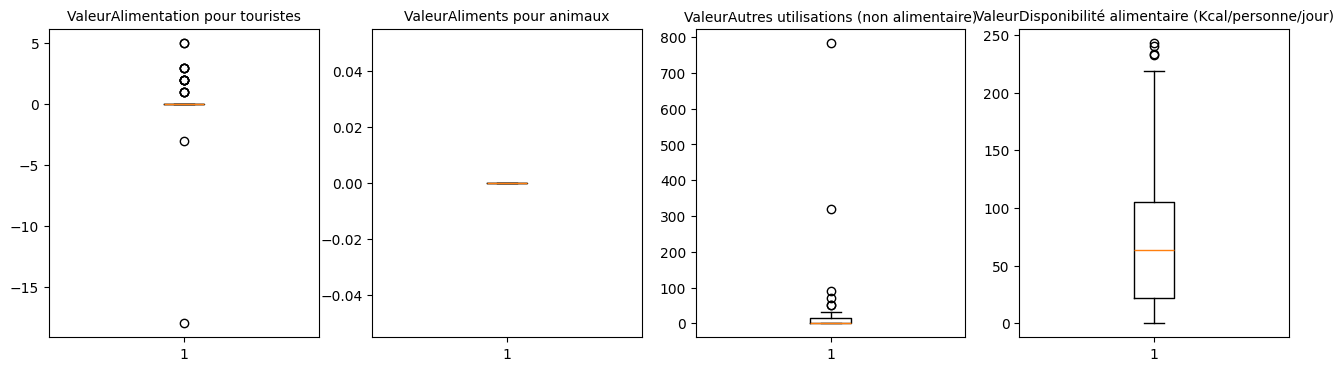

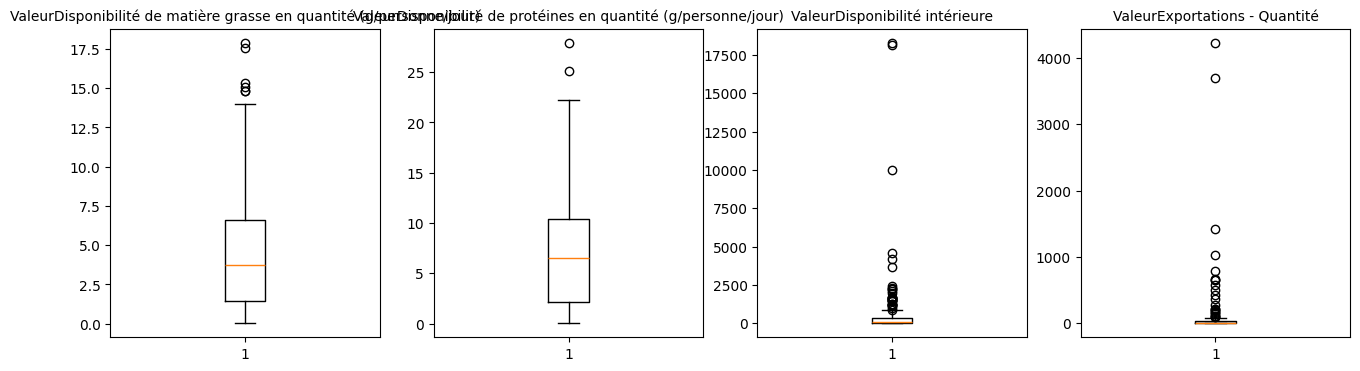

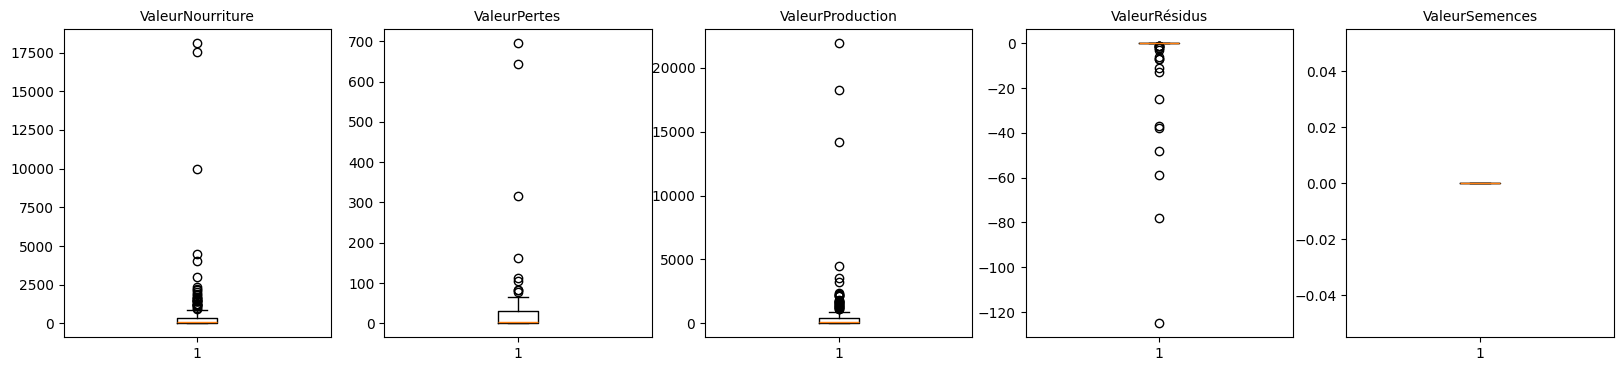

In [54]:
plot_data(dispoA_flat, dispoA_flat.columns[1:5].to_list())
plot_data(dispoA_flat, dispoA_flat.columns[6:10].to_list())
plot_data(dispoA_flat, dispoA_flat.columns[11:16].to_list()) 
# valeurAliments pour animaux, valeurSemences n'ont pas de valeurs intéressantes
# il existe des caractéristiques bien assymétriques

### Jointure avec pays

In [55]:
# corrige les noms
zones = ["Arabie saoudite", "Bolivie ", "Chine - RAS de Hong-Kong", "Chine - RAS de Macao", "Bélarus", 
        "Fédération de Russie", "Iran ", "Guinée équatoriale", "Libéria", "Micronésie ", "Ouganda", "Palestine", 
        "États-Unis ", "République de Corée", "République populaire démocratique de Corée", 
        "République démocratique du Congo", "République arabe syrienne", "République-Unie de Tanzanie", 
        "Saint-Vincent-et-les Grenadines", "Tchéquie", "Trinité-et-Tobago", "Türkiye","Venezuela", "Viet Nam", 
        "Égypte", "Émirats arabes unis", "Érythrée", "Éthiopie", "Maurice", "Équateur", "Côte d'Ivoire", 
        "El Salvador", "Cabo Verde", "de Moldova", "Chine, Taiwan Province de", "Royaume-Uni", "Chine, continentale"]

zones_remp = ["Arabie Saoudite", "Bolivie", "Hong Kong (Chine)", "Macao (Chine)", "Biélorussie", 
             "Russie", "Iran", "Guinée-Équatoriale", "Liberia", "Micronesie", "Uganda", "Territoires palestiniens",
              "Etats-Unis", "Corée du Nord", "Corée du Sud", 
              "Congo (Rép. dém.)", "Syrie", "Tanzanie",
             "Saint-Vincent-et-les-Grenadines", "République tchèque", "Trinité et Tobago", "Turquie", "Venezuela", "Viêt Nam", 
             "Egypte", "Emirats arabes unis", "Erythrée", "Ethiopie", "Ile Maurice", "Equateur", "Côte dIvoire", 
             "Salvador", "Cap Vert", "Moldavie", "Taïwan", "Royaume-Uni", "Chine"]


correction_zones(zones, zones_remp, dispoA_flat)

In [56]:
dispoA_flat.loc[dispoA_flat["Zone"].duplicated()] # Pas duplication

,Zone,ValeurAlimentation pour touristes,ValeurAliments pour animaux,ValeurAutres utilisations (non alimentaire),ValeurDisponibilité alimentaire (Kcal/personne/jour),ValeurDisponibilité alimentaire en quantité (kg/personne/an),ValeurDisponibilité de matière grasse en quantité (g/personne/jour),ValeurDisponibilité de protéines en quantité (g/personne/jour),ValeurDisponibilité intérieure,ValeurExportations - Quantité,ValeurImportations - Quantité,ValeurNourriture,ValeurPertes,ValeurProduction,ValeurRésidus,ValeurSemences,ValeurTraitement,ValeurVariation de stock


In [57]:
pays_dispo = pd.merge(codepays, dispoA_flat, how = "outer", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_dispo.loc[pays_dispo["_merge"]=="right_only"] # pas important

,iso3,name_en,name_fr,iso2,Zone,ValeurAlimentation pour touristes,ValeurAliments pour animaux,ValeurAutres utilisations (non alimentaire),ValeurDisponibilité alimentaire (Kcal/personne/jour),ValeurDisponibilité alimentaire en quantité (kg/personne/an),...,ValeurExportations - Quantité,ValeurImportations - Quantité,ValeurNourriture,ValeurPertes,ValeurProduction,ValeurRésidus,ValeurSemences,ValeurTraitement,ValeurVariation de stock,_merge
90,NaN,NaN,NaN,NaN,Iraq,0.0,NaN,NaN,52.0,14.95,...,0.0,470.0,561.0,5.0,96.0,0.0,NaN,NaN,0.0,right_only
130,NaN,NaN,NaN,NaN,Myanmar,0.0,NaN,NaN,116.0,30.37,...,0.0,3.0,1621.0,45.0,1662.0,0.0,NaN,NaN,-1.0,right_only
137,NaN,NaN,NaN,NaN,Nouvelle-Calédonie,0.0,NaN,NaN,136.0,38.71,...,NaN,9.0,11.0,NaN,1.0,0.0,NaN,NaN,-1.0,right_only
150,NaN,NaN,NaN,NaN,Polynésie française,2.0,NaN,0.0,167.0,47.40,...,0.0,15.0,13.0,NaN,1.0,0.0,NaN,NaN,0.0,right_only
162,NaN,NaN,NaN,NaN,République démocratique populaire lao,NaN,NaN,NaN,41.0,10.91,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,right_only
166,NaN,NaN,NaN,NaN,Saint-Kitts-et-Nevis,1.0,NaN,0.0,190.0,55.77,...,0.0,4.0,3.0,NaN,0.0,0.0,NaN,NaN,0.0,right_only
197,NaN,NaN,NaN,NaN,Timor-Leste,NaN,NaN,NaN,14.0,4.24,...,NaN,11.0,5.0,NaN,1.0,0.0,NaN,NaN,7.0,right_only


In [58]:
pays_dispo.loc[pays_dispo["name_fr"].str.contains("unis", case = False, na = False)].head() # bien intégré

,iso3,name_en,name_fr,iso2,Zone,ValeurAlimentation pour touristes,ValeurAliments pour animaux,ValeurAutres utilisations (non alimentaire),ValeurDisponibilité alimentaire (Kcal/personne/jour),ValeurDisponibilité alimentaire en quantité (kg/personne/an),...,ValeurExportations - Quantité,ValeurImportations - Quantité,ValeurNourriture,ValeurPertes,ValeurProduction,ValeurRésidus,ValeurSemences,ValeurTraitement,ValeurVariation de stock,_merge
56,ARE,United Arab Emirates,Emirats arabes unis,AE,Emirats arabes unis,NaN,NaN,NaN,147.0,43.47,...,94.0,433.0,412.0,NaN,48.0,0.0,NaN,NaN,-26.0,both
62,USA,United States of America,Etats-Unis,US,Etats-Unis,NaN,NaN,89.0,219.0,55.68,...,3692.0,123.0,18100.0,NaN,21914.0,0.0,NaN,77.0,80.0,both
201,TUN,Tunisia,Tunisie,TN,Tunisie,NaN,NaN,NaN,57.0,17.03,...,4.0,0.0,195.0,NaN,213.0,0.0,NaN,NaN,15.0,both


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - Sécurité alimentaire </h3>
</div>

La sécurité alimentaire est caractérisée par plusieurs variables listées ci-dessou :
- Nombre de personnes sous-alimentées (millions) (moyenne sur 3 ans)
- Prévalence de la sous-alimentation (%) (moyenne sur 3 ans)
- Pourcentage de la population utilisant au moins les services d'assainissement de base
- Prévalence de l'obésité chez l'adulte (18 ans ou plus)
- Besoins énergétiques alimentaires minimaux (kcal/personne/jour)
- Stabilité politique et absence de violence/terrorisme (indice)
- Valeur des importations alimentaires par rapport aux exportations totales de marchandises (%) (moyenne sur 3 ans)
- PIB par habitant, ($ PPA internationaux constants de 2021)
- Part des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)
- Disponibilités protéiques moyennes (g/personne/jour) (moyenne sur 3 ans)
- Disponibilités moyennes de matière grasse (g/personne/jour) (moyenne sur 3 ans)
- Disponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans)
- Pourcentage des terres arables aménagées pour l'irrigation (%) (moyenne sur 3 ans)
- Suffisance des apports énergétiques alimentaires moyens (%) (moyenne sur 3 ans)
- Disponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour)
- Disponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour) (moyenne sur 3 ans)
- Variabilité des disponibilités alimentaires par habitant (Kcal/personne/jour)
- Taux de dépendance à l'égard des importations céréalières (%) (moyenne sur 3 ans)
- Pourcentage de la population ayant accès à des services d'assainissement gérés en toute sécurité

Ces données proviennent toutes de la FAO.

In [59]:
secuAli.info()
secuAli.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3456 entries, FS to FS
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Domaine                 3456 non-null   object 
 1   Code zone (M49)         3456 non-null   int64  
 2   Zone                    3456 non-null   object 
 3   Code Élément            3456 non-null   int64  
 4   Élément                 3456 non-null   object 
 5   Code Produit            3456 non-null   int64  
 6   Produit                 3456 non-null   object 
 7   Code année              3456 non-null   int64  
 8   Année                   3456 non-null   object 
 9   Unité                   3261 non-null   object 
 10  Valeur                  3332 non-null   object 
 11  Symbole                 3456 non-null   object 
 12  Description du Symbole  3456 non-null   object 
 13  Note                    0 non-null      float64
dtypes: float64(1), int64(4), object(9)
memory usag

,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
Code Domaine,,,,,,,,,,,,,,
FS,Données de la sécurité alimentaire,4,Afghanistan,6121,Valeur,21010,Suffisance des apports énergétiques alimentair...,20162018,2016-2018,%,107,E,Valeur estimée,NaN
FS,Données de la sécurité alimentaire,4,Afghanistan,6128,Valeur,220001,Disponibilité alimentaire par habitant utilisé...,2017,2017,kcal/personne/jour,2307,E,Valeur estimée,NaN
FS,Données de la sécurité alimentaire,4,Afghanistan,6128,Valeur,22000,Disponibilité alimentaire par habitant utilisé...,20162018,2016-2018,kcal/personne/jour,2270,E,Valeur estimée,NaN
FS,Données de la sécurité alimentaire,4,Afghanistan,6121,Valeur,21012,"Part des céréales, des racines et des tubercul...",20162018,2016-2018,%,71,E,Valeur estimée,NaN
FS,Données de la sécurité alimentaire,4,Afghanistan,6123,Valeur,21013,Disponibilités protéiques moyennes (g/personne...,20162018,2016-2018,g/personne/jour,64.4,E,Valeur estimée,NaN


### Sécurité alimentaire en 2017

In [60]:
# Sélectionner les lignes et colonnes 
secuAli = secuAli[["Zone", "Produit", "Année", "Valeur"]]

# Harmoniser l'année
secuAli["Année"] = 2017
secuAli["Valeur"] = pd.to_numeric(secuAli["Valeur"], errors = "coerce")

In [61]:
# donnees à pivoter
secuAli_flat = pivoter_data(secuAli, "Zone", "Produit")
secuAli_flat.info()
secuAli_flat.head() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 20 columns):
 #   Column                                                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                                                     --------------  -----  
 0   Zone                                                                                                                                                       204 non-null    object 
 1   ValeurBesoins énergétiques alimentaires minimaux (kcal/personne/jour)                                                                                      196 non-null    float64
 2   ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour)                     

,Zone,ValeurBesoins énergétiques alimentaires minimaux (kcal/personne/jour),ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour),ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour) (moyenne sur 3 ans),ValeurDisponibilités moyennes de matière grasse (g/personne/jour) (moyenne sur 3 ans),ValeurDisponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans),ValeurDisponibilités protéiques moyennes (g/personne/jour) (moyenne sur 3 ans),ValeurNombre de personnes sous-alimentées (millions) (moyenne sur 3 ans),"ValeurPIB par habitant, ($ PPA internationaux constants de 2021)","ValeurPart des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)",ValeurPourcentage de la population ayant accès à des services d'assainissement gérés en toute sécurité,ValeurPourcentage de la population utilisant au moins les services d'assainissement de base,ValeurPourcentage des terres arables aménagées pour l'irrigation (%) (moyenne sur 3 ans),ValeurPrévalence de l'obésité chez l'adulte (18 ans ou plus),ValeurPrévalence de la sous-alimentation (%) (moyenne sur 3 ans),ValeurStabilité politique et absence de violence/terrorisme (indice),ValeurSuffisance des apports énergétiques alimentaires moyens (%) (moyenne sur 3 ans),ValeurTaux de dépendance à l'égard des importations céréalières (%) (moyenne sur 3 ans),ValeurValeur des importations alimentaires par rapport aux exportations totales de marchandises (%) (moyenne sur 3 ans),ValeurVariabilité des disponibilités alimentaires par habitant (Kcal/personne/jour)
0,Afghanistan,1646.0,2307.0,2270.0,41.5,11.7,64.4,7.6,2953.0,71.0,NaN,48.0,4.9,14.3,21.3,-2.79,107.0,43.9,378.0,26.0
1,Afrique du Sud,1834.0,2835.0,2827.0,86.0,38.5,78.7,3.5,14591.4,51.0,68.0,74.0,1.5,29.6,6.1,-0.28,119.0,22.7,6.0,18.0
2,Albanie,1909.0,3355.0,3344.0,117.5,63.9,116.3,0.1,14155.0,34.0,46.0,98.0,12.9,20.2,4.3,0.37,135.0,45.9,21.0,39.0
3,Algérie,1786.0,3395.0,3414.0,99.8,28.8,93.6,1.0,15427.7,48.0,62.0,86.0,0.6,21.3,2.5,-0.92,148.0,74.3,23.0,27.0
4,Allemagne,1958.0,3576.0,3588.0,149.4,70.1,110.3,NaN,61991.5,27.0,97.0,99.0,1.9,20.4,NaN,0.57,141.0,-1.5,5.0,14.0


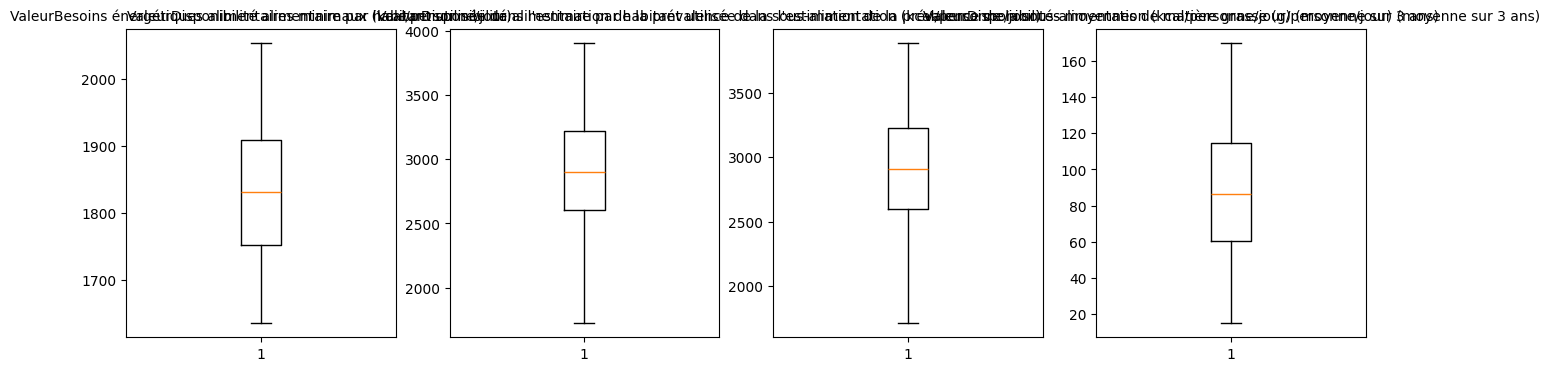

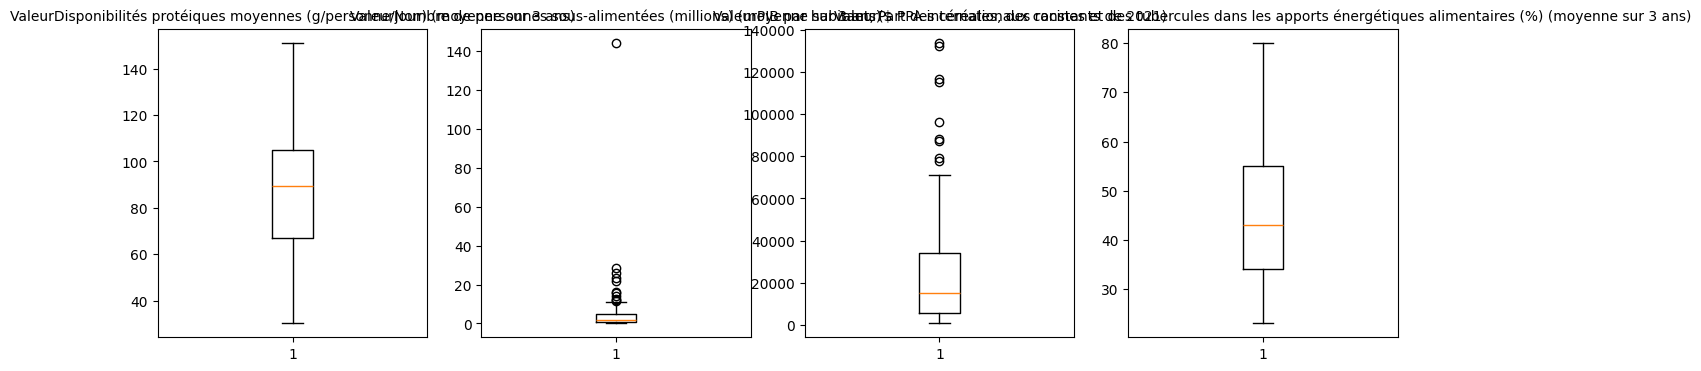

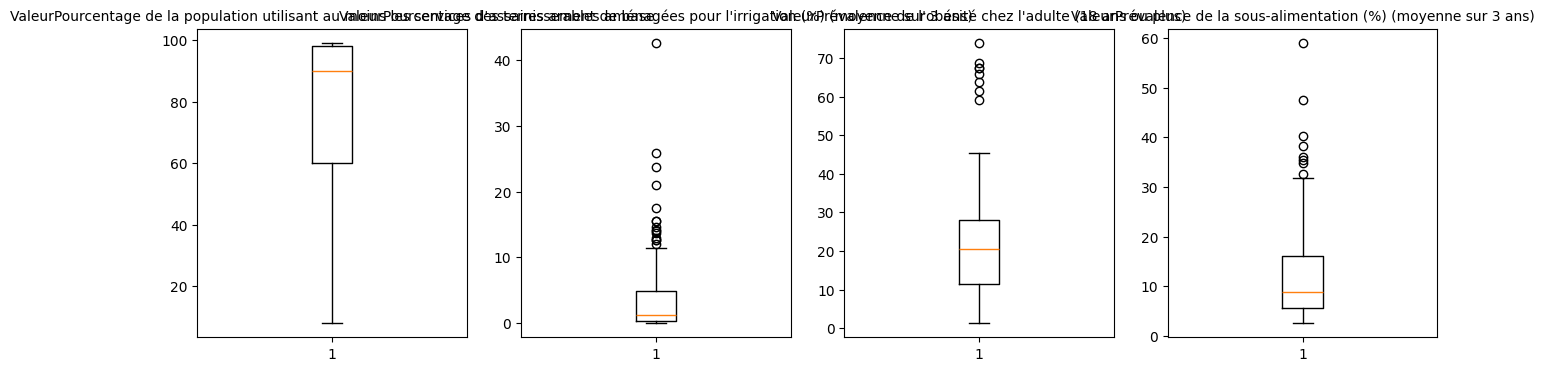

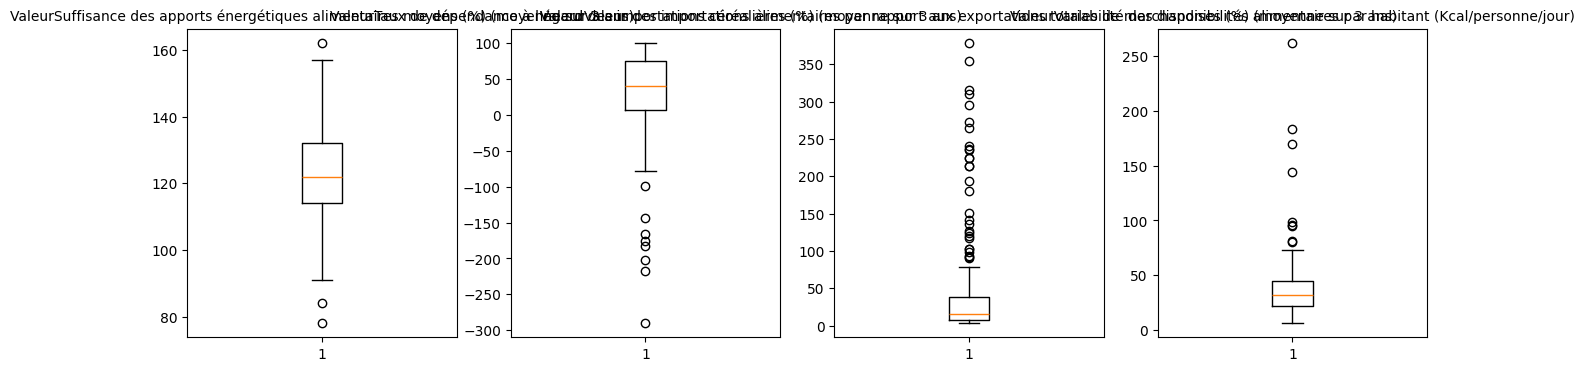

In [62]:
plot_data(secuAli_flat, secuAli_flat.columns[1:5].to_list())
plot_data(secuAli_flat, secuAli_flat.columns[6:10].to_list())
plot_data(secuAli_flat, secuAli_flat.columns[11:15].to_list())
plot_data(secuAli_flat, secuAli_flat.columns[16:20].to_list()) 
# certaines distributions sont très assymétriques 

### Jointure avec pays

In [63]:
# corrige les noms de pays
zones = ["Arabie saoudite", "Bolivie ", "Chine - RAS de Hong-Kong", "Chine - RAS de Macao", "Bélarus", 
        "Fédération de Russie", "Iran ", "Guinée équatoriale", "Libéria", "Micronésie ", "Ouganda", "Palestine", 
        "États-Unis ", "République de Corée", "République populaire démocratique de Corée", 
        "République démocratique du Congo", "République arabe syrienne", "République-Unie de Tanzanie", 
        "Saint-Vincent-et-les Grenadines", "Tchéquie", "Trinité-et-Tobago", "Türkiye","Venezuela", "Viet Nam", 
        "Égypte", "Émirats arabes unis", "Érythrée", "Éthiopie", "Maurice",
        "El Salvador", "de Moldova", "Chine, Taiwan Province de"]

zones_remp = ["Arabie Saoudite", "Bolivie", "Hong Kong (Chine)", "Macao (Chine)", "Biélorussie", 
             "Russie", "Iran", "Guinée-Équatoriale", "Liberia", "Micronesie", "Uganda", "Territoires palestiniens",
             "Etats-Unis", "Corée du Nord", "Corée du Sud", 
            "Congo (Rép. dém.)", "Syrie", "Tanzanie",
             "Saint-Vincent-et-les-Grenadines", "République tchèque", "Trinité et Tobago", "Turquie", "Venezuela", "Viêt Nam", 
             "Egypte", "Emirats arabes unis", "Erythrée", "Éthiopie", "Ile Maurice", 
             "Salvador", "Moldavie", "Taïwan"]


correction_zones(zones, zones_remp, secuAli_flat)

In [64]:
secuAli_flat.loc[secuAli_flat["Zone"].duplicated()] # Pas duplication

,Zone,ValeurBesoins énergétiques alimentaires minimaux (kcal/personne/jour),ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour),ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour) (moyenne sur 3 ans),ValeurDisponibilités moyennes de matière grasse (g/personne/jour) (moyenne sur 3 ans),ValeurDisponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans),ValeurDisponibilités protéiques moyennes (g/personne/jour) (moyenne sur 3 ans),ValeurNombre de personnes sous-alimentées (millions) (moyenne sur 3 ans),"ValeurPIB par habitant, ($ PPA internationaux constants de 2021)","ValeurPart des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)",ValeurPourcentage de la population ayant accès à des services d'assainissement gérés en toute sécurité,ValeurPourcentage de la population utilisant au moins les services d'assainissement de base,ValeurPourcentage des terres arables aménagées pour l'irrigation (%) (moyenne sur 3 ans),ValeurPrévalence de l'obésité chez l'adulte (18 ans ou plus),ValeurPrévalence de la sous-alimentation (%) (moyenne sur 3 ans),ValeurStabilité politique et absence de violence/terrorisme (indice),ValeurSuffisance des apports énergétiques alimentaires moyens (%) (moyenne sur 3 ans),ValeurTaux de dépendance à l'égard des importations céréalières (%) (moyenne sur 3 ans),ValeurValeur des importations alimentaires par rapport aux exportations totales de marchandises (%) (moyenne sur 3 ans),ValeurVariabilité des disponibilités alimentaires par habitant (Kcal/personne/jour)


In [65]:
pays_secu = pd.merge(codepays, secuAli_flat, how = "outer", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_secu.loc[pays_secu["_merge"]== "right_only"].head() # les plus importants ne sont pas là ou en duplicate

,iso3,name_en,name_fr,iso2,Zone,ValeurBesoins énergétiques alimentaires minimaux (kcal/personne/jour),ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour),ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour) (moyenne sur 3 ans),ValeurDisponibilités moyennes de matière grasse (g/personne/jour) (moyenne sur 3 ans),ValeurDisponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans),...,ValeurPourcentage de la population utilisant au moins les services d'assainissement de base,ValeurPourcentage des terres arables aménagées pour l'irrigation (%) (moyenne sur 3 ans),ValeurPrévalence de l'obésité chez l'adulte (18 ans ou plus),ValeurPrévalence de la sous-alimentation (%) (moyenne sur 3 ans),ValeurStabilité politique et absence de violence/terrorisme (indice),ValeurSuffisance des apports énergétiques alimentaires moyens (%) (moyenne sur 3 ans),ValeurTaux de dépendance à l'égard des importations céréalières (%) (moyenne sur 3 ans),ValeurValeur des importations alimentaires par rapport aux exportations totales de marchandises (%) (moyenne sur 3 ans),ValeurVariabilité des disponibilités alimentaires par habitant (Kcal/personne/jour),_merge
29,NaN,NaN,NaN,NaN,Brunéi Darussalam,1869.0,NaN,NaN,NaN,NaN,...,93.0,0.2,27.4,NaN,1.15,NaN,NaN,7.0,NaN,right_only
35,NaN,NaN,NaN,NaN,Cabo Verde,1859.0,2557.0,2566.0,68.5,31.2,...,75.0,0.9,13.3,15.5,0.76,107.0,92.2,NaN,32.0,right_only
42,NaN,NaN,NaN,NaN,"Chine, continentale",1880.0,3261.0,3254.0,87.9,46.7,...,NaN,7.9,NaN,NaN,NaN,134.0,3.5,4.0,29.0,right_only
54,NaN,NaN,NaN,NaN,Côte d'Ivoire,1723.0,2805.0,2795.0,49.7,15.0,...,33.0,0.2,9.6,10.6,-1.09,126.0,44.2,12.0,48.0,right_only
94,NaN,NaN,NaN,NaN,Iraq,1754.0,2624.0,2629.0,69.7,19.5,...,96.0,8.1,37.6,16.0,-2.30,116.0,62.9,14.0,28.0,right_only


In [66]:
pays_secu.loc[pays_secu["name_fr"].str.contains("chin", case=False, na = False)] # Pas de problème

,iso3,name_en,name_fr,iso2,Zone,ValeurBesoins énergétiques alimentaires minimaux (kcal/personne/jour),ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour),ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour) (moyenne sur 3 ans),ValeurDisponibilités moyennes de matière grasse (g/personne/jour) (moyenne sur 3 ans),ValeurDisponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans),...,ValeurPourcentage de la population utilisant au moins les services d'assainissement de base,ValeurPourcentage des terres arables aménagées pour l'irrigation (%) (moyenne sur 3 ans),ValeurPrévalence de l'obésité chez l'adulte (18 ans ou plus),ValeurPrévalence de la sous-alimentation (%) (moyenne sur 3 ans),ValeurStabilité politique et absence de violence/terrorisme (indice),ValeurSuffisance des apports énergétiques alimentaires moyens (%) (moyenne sur 3 ans),ValeurTaux de dépendance à l'égard des importations céréalières (%) (moyenne sur 3 ans),ValeurValeur des importations alimentaires par rapport aux exportations totales de marchandises (%) (moyenne sur 3 ans),ValeurVariabilité des disponibilités alimentaires par habitant (Kcal/personne/jour),_merge
41,CHN,China,Chine,CN,Chine,1881.0,3254.0,3248.0,88.7,47.1,...,NaN,NaN,6.1,NaN,NaN,134.0,4.5,4.0,28.0,both
87,HKG,Hong Kong,Hong Kong (Chine),HK,Hong Kong (Chine),1892.0,3150.0,3140.0,125.7,102.4,...,96.0,1.0,NaN,NaN,0.82,128.0,99.7,4.0,22.0,both
117,MAC,Macao,Macao (Chine),MO,Macao (Chine),1899.0,3199.0,3197.0,144.9,78.9,...,99.0,NaN,NaN,6.0,1.41,130.0,NaN,103.0,34.0,both


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - Inflation alimentaire </h3>
</div>

L'une des principales caractéristiques utilisées pour le calcul de l'IPC est l'inflation des prix à la consommation alimentaire. 

Elle est fondamentale pour réflèter l'aspect économique d'un pays.

In [67]:
foodInfla.info()
foodInfla.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2420 entries, CP to CP
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Domaine                 2420 non-null   object 
 1   Code zone (M49)         2420 non-null   int64  
 2   Zone                    2420 non-null   object 
 3   Code année              2420 non-null   int64  
 4   Année                   2420 non-null   int64  
 5   Code Produit            2420 non-null   int64  
 6   Produit                 2420 non-null   object 
 7   Code Mois               2420 non-null   int64  
 8   Mois                    2420 non-null   object 
 9   Code Élément            2420 non-null   int64  
 10  Élément                 2420 non-null   object 
 11  Unité                   2420 non-null   object 
 12  Valeur                  2420 non-null   float64
 13  Symbole                 2420 non-null   object 
 14  Description du Symbole  2420 non-null   object

,Domaine,Code zone (M49),Zone,Code année,Année,Code Produit,Produit,Code Mois,Mois,Code Élément,Élément,Unité,Valeur,Symbole,Description du Symbole,Note
Code Domaine,,,,,,,,,,,,,,,,
CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7001,Janvier,6121,Valeur,%,4.730651,E,Valeur estimée,NaN
CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7002,Février,6121,Valeur,%,4.553673,E,Valeur estimée,NaN
CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7003,Mars,6121,Valeur,%,10.028383,E,Valeur estimée,NaN
CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7004,Avril,6121,Valeur,%,9.367880,E,Valeur estimée,NaN
CP,Indices de Prix à la Consommation,4,Afghanistan,2017,2017,23014,Food price inflation,7005,Mai,6121,Valeur,%,10.723921,E,Valeur estimée,NaN


In [68]:
foodInfla_ = foodInfla[["Zone", "Valeur"]]
foodInf = foodInfla_.groupby(["Zone"]).mean().reset_index() # les données en mois en données en année
foodInf.rename(columns = {"Valeur" : "food_infla"}, inplace = True)

In [69]:
foodInf.describe() # assymétrique mais valeur négative existent donc on ne peut pas utiliser la fonction logarithmique

,food_infla
count,203.000000
mean,7.858457
std,37.744952
min,-3.718112
25%,0.595167
50%,2.407079
75%,5.749607
max,480.863389


### Jointure avec pays

In [70]:
# corrige les noms
zones = ["Arabie saoudite", "Bolivie ", "Chine - RAS de Hong-Kong", "Chine - RAS de Macao", "Bélarus", "Iraq",
        "Fédération de Russie", "Iran ", "Guinée équatoriale", "Libéria", "Micronésie ", "Ouganda", "Palestine", 
        "États-Unis d'Amérique", "République de Corée", "République populaire démocratique de Corée", 
        "République démocratique du Congo", "République arabe syrienne", "République-Unie de Tanzanie", 
        "Saint-Vincent-et-les Grenadines", "Tchéquie", "Trinité-et-Tobago", "Türkiye","Venezuela", "Viet Nam", 
        "Égypte", "Émirats arabes unis", "Érythrée", "Éthiopie", "Maurice", "Pays-Bas ", "Équateur", "Côte d'Ivoire", 
        "El Salvador", "Cabo Verde", "de Moldova", "Chine, Taiwan Province de", "Chine, continentale"]

zones_remp = ["Arabie Saoudite", "Bolivie", "Hong Kong (Chine)", "Macao (Chine)", "Biélorussie", "Irak",
             "Russie", "Iran", "Guinée-Équatoriale", "Liberia", "Micronesie", "Uganda", "Territoires palestiniens",
              "Etats-Unis", "Corée du Nord", "Corée du Sud", 
              "Congo (Rép. dém.)", "Syrie", "Tanzanie",
             "Saint-Vincent-et-les-Grenadines", "République tchèque", "Trinité et Tobago", "Turquie", "Venezuela", "Viêt Nam", 
             "Egypte", "Emirats arabes unis", "Erythrée", "Ethiopie", "Ile Maurice", "Pays-Bas", "Equateur", "Côte dIvoire", 
             "Salvador", "Cap Vert", "Moldavie", "Taïwan", "Chine"]


correction_zones(zones, zones_remp, foodInf)

In [71]:
foodInf.loc[foodInf["Zone"].duplicated()] # Pas duplication

,Zone,food_infla


In [72]:
pays_infla = pd.merge(codepays, foodInf, how = "outer", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_infla.loc[pays_infla["_merge"]== "right_only"].head() # Pas important

,iso3,name_en,name_fr,iso2,Zone,food_infla,_merge
7,NaN,NaN,NaN,NaN,Anguilla,1.203278,right_only
30,NaN,NaN,NaN,NaN,Brunéi Darussalam,0.280608,right_only
76,NaN,NaN,NaN,NaN,Guadeloupe,1.468704,right_only
83,NaN,NaN,NaN,NaN,Guyane française,0.644719,right_only
125,NaN,NaN,NaN,NaN,Martinique,1.148400,right_only


In [73]:
pays_infla.loc[pays_infla["name_fr"].str.contains("unis", case = False, na = False)] # bien intégré

,iso3,name_en,name_fr,iso2,Zone,food_infla,_merge
58,ARE,United Arab Emirates,Emirats arabes unis,AE,Emirats arabes unis,1.212139,both
64,USA,United States of America,Etats-Unis,US,Etats-Unis,-0.195678,both
209,TUN,Tunisia,Tunisie,TN,Tunisie,5.629163,both


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">0 - IPP </h3>
</div>

L'IPP est l'indice des prix à la production. C'est un indicateur important de l’inflation chez les consommateurs, car des prix plus élevés fixés par les producteurs se répercutent sur ceux-ci.

Elle est aussi une caractéristique réflétant l'économie.

In [74]:
ipp.info()
ipp.head()

<class 'pandas.core.frame.DataFrame'>
Index: 142 entries, PP to PP
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Domaine                 142 non-null    object 
 1   Code zone (M49)         142 non-null    int64  
 2   Zone                    142 non-null    object 
 3   Code Élément            142 non-null    int64  
 4   Élément                 142 non-null    object 
 5   Code Produit (CPC)      142 non-null    int64  
 6   Produit                 142 non-null    object 
 7   Code année              142 non-null    int64  
 8   Année                   142 non-null    int64  
 9   Code Mois               142 non-null    int64  
 10  Mois                    142 non-null    object 
 11  Unité                   0 non-null      float64
 12  Valeur                  142 non-null    float64
 13  Symbole                 142 non-null    object 
 14  Description du Symbole  142 non-null    object 

,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit (CPC),Produit,Code année,Année,Code Mois,Mois,Unité,Valeur,Symbole,Description du Symbole
Code Domaine,,,,,,,,,,,,,,,
PP,Prix à la Production,4,Afghanistan,5539,Indice des prix à la production (2014-2016 = 100),21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,7021,Valeur annuel,NaN,89.57,I,Valeur imputée par une agence réceptrice
PP,Prix à la Production,710,Afrique du Sud,5539,Indice des prix à la production (2014-2016 = 100),21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,7021,Valeur annuel,NaN,125.65,I,Valeur imputée par une agence réceptrice
PP,Prix à la Production,8,Albanie,5539,Indice des prix à la production (2014-2016 = 100),21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,7021,Valeur annuel,NaN,80.33,I,Valeur imputée par une agence réceptrice
PP,Prix à la Production,12,Algérie,5539,Indice des prix à la production (2014-2016 = 100),21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,7021,Valeur annuel,NaN,94.16,I,Valeur imputée par une agence réceptrice
PP,Prix à la Production,276,Allemagne,5539,Indice des prix à la production (2014-2016 = 100),21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,7021,Valeur annuel,NaN,88.32,I,Valeur imputée par une agence réceptrice


In [75]:
ipp_ = ipp.copy()[["Zone", "Valeur"]]
ipp_.rename(columns = {"Valeur" : "IPP"}, inplace = True)

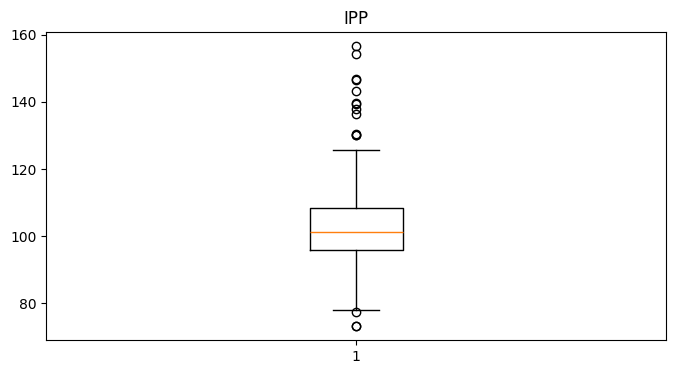

In [76]:
plt.subplots(1,1, figsize=(8, 4))
plt.boxplot(ipp_["IPP"].dropna())
plt.title(f"{ipp_.columns[1]}")
plt.show() # distribution assez symétrique avec valeur positive, avec quelque valeurs extremes

### Jointure avec pays

In [77]:
# corrige les noms
zones = ["Arabie saoudite", "Bolivie ", "Chine - RAS de Hong-Kong", "Chine - RAS de Macao", "Bélarus", 
        "Fédération de Russie", "Iran ", "Guinée équatoriale", "Libéria", "Micronésie ", "Ouganda", "Palestine", 
        "États-Unis ", "République de Corée", "République populaire démocratique de Corée", 
        "République démocratique du Congo", "République arabe syrienne", "République-Unie de Tanzanie", 
        "Saint-Vincent-et-les Grenadines", "Tchéquie", "Trinité-et-Tobago", "Türkiye","Venezuela", "Viet Nam", 
        "Égypte", "Émirats arabes unis", "Érythrée", "Éthiopie", "Maurice", "Pays-Bas ", "Équateur", "Côte d'Ivoire", 
        "El Salvador", "Cabo Verde", "de Moldova", " Taiwan Province de", "continentale"]

zones_remp = ["Arabie Saoudite", "Bolivie", "Hong Kong (Chine)", "Macao (Chine)", "Biélorussie", 
             "Russie", "Iran", "Guinée-Équatoriale", "Liberia", "Micronesie", "Uganda", "Territoires palestiniens",
             "Etats-Unis", "Corée du Nord", "Corée du Sud", 
              "Congo (Rép. dém.)", "Syrie", "Tanzanie",
             "Saint-Vincent-et-les-Grenadines", "République tchèque", "Trinité et Tobago", "Turquie", "Venezuela", "Viêt Nam", 
             "Egypte", "Emirats arabes unis", "Erythrée", "Ethiopie", "Ile Maurice", "Pays-Bas", "Equateur", "Côte dIvoire", 
             "Salvador", "Cap Vert", "Moldavie", "Taïwan", "Chine"]


correction_zones(zones, zones_remp, ipp_)

In [78]:
ipp_.loc[ipp_["Zone"].duplicated()] # Pas duplication

,Zone,IPP
Code Domaine,,


In [79]:
pays_ipp = pd.merge(codepays, ipp_, how = "outer", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_ipp.loc[pays_ipp["_merge"]== "right_only"]
# Pas important

,iso3,name_en,name_fr,iso2,Zone,IPP,_merge
29,NaN,NaN,NaN,NaN,Brunéi Darussalam,89.32,right_only
130,NaN,NaN,NaN,NaN,Myanmar,90.84,right_only
156,NaN,NaN,NaN,NaN,Royaume-Uni de Grande-Bretagne et d'Irlande du...,102.33,right_only
161,NaN,NaN,NaN,NaN,République démocratique populaire lao,101.49,right_only
214,NaN,NaN,NaN,NaN,Îles Cook,87.49,right_only


In [80]:
pays_ipp.loc[pays_ipp["name_fr"].str.contains("unis", case = False, na = False)]  # bien intégré

,iso3,name_en,name_fr,iso2,Zone,IPP,_merge
57,ARE,United Arab Emirates,Emirats arabes unis,AE,NaN,NaN,left_only
63,USA,United States of America,Etats-Unis,US,Etats-Unis,99.59,both
198,TUN,Tunisia,Tunisie,TN,Tunisie,105.12,both


<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">1 - Jointure de l'ensemble des données </h2>
</div>

On commence ici une jointure deux à deux jusqu'à obtenir un jeu de données final contenant toutes les caractéristiques qu'on a trouvé ci-dessu.

In [81]:
# Jointure entre code et culture_reg
pays_culture = pd.merge(codepays, culture_reg1, how = "left", left_on = "iso3", right_on = "REF_AREA", indicator=True).reset_index(drop=True)
pays_culture.rename(columns={"_merge": "_merge_culture", "OBS_VALUE": "culture"}, inplace=True)
pays_culture = pays_culture.drop(columns=["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD"])

In [82]:
# Jointure entre pays_culture et emission de gaz à effet de serre
pays_cul_emi = pd.merge(pays_culture, emission_flat, how = "left", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_cul_emi.rename(columns={"ValeurRéserves": "ResPoulet", "ValeurTotal imputable à l'élevage (émissions CH4)": "CH4", 
                         "ValeurTotal imputable à l'élevage (émissions N2O)" : "N2O", "_merge" : "_merge_emi"}, inplace=True)
pays_cul_emi.drop(columns = ["Zone"], inplace = True)


In [83]:
# Jointure avec emploi
pays_cul_emi_emploi = pd.merge(pays_cul_emi, emploi_rural1, how = "left", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_cul_emi_emploi.rename(columns={"Valeur" : "emploi_rural", "_merge" : "_merge_emp"}, inplace=True)
pays_cul_emi_emploi.drop(columns = ["Zone"], inplace = True)


In [84]:
# Jointure avec paiement internet
pays_cul_emi_emp_wb = pd.merge(pays_cul_emi_emploi, wb_payment1, how = "left", left_on = "iso3", right_on = "REF_AREA", indicator=True).reset_index(drop=True)
pays_cul_emi_emp_wb.rename(columns={"OBS_VALUE": "payment", "_merge" : "_merge_payment"}, inplace=True)
pays_cul_emi_emp_wb.drop(columns = ["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD"], inplace = True)


pays_cul_emi_emp_wb.loc[pays_cul_emi_emp_wb.duplicated("name_fr")] 
# Il n'y a pas de doulons

,iso3,name_en,name_fr,iso2,culture,_merge_culture,ResPoulet,CH4,N2O,_merge_emi,emploi_rural,_merge_emp,payment,_merge_payment


In [85]:
# Jointure avec pop
pays_ceew_pop = pd.merge(pays_cul_emi_emp_wb, pop17, how = "left", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_ceew_pop.rename(columns={"Valeur" : "pop", "_merge" : "_merge_pop"}, inplace=True)
pays_ceew_pop.drop(columns = ["Zone"], inplace = True)


In [86]:
# Jointure avec disponibilité alimentaire
pays_ceewp_dispo = pd.merge(pays_ceew_pop, dispoA_flat, how = "left", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_ceewp_dispo.rename(columns={"_merge" : "_merge_dispo", "ValeurDisponibilité alimentaire (Kcal/personne/jour)" : "dispoA_kcal", 
                                "ValeurDisponibilité alimentaire en quantité (kg/personne/an)" : "dispoA_qt", 
                                "ValeurDisponibilité de matière grasse en quantité (g/personne/jour)" : "dispo_grasse_qt", 
                                "ValeurDisponibilité de protéines en quantité (g/personne/jour)" : "proteine_qt", 
                                "ValeurDisponibilité intérieure" : "dispo_Interne", "ValeurExportations - Quantité" : "export", 
                                "ValeurImportations - Quantité" : "import", "ValeurNourriture" : "nourriture", "ValeurProduction" : "production", 
                                "ValeurRésidus" : "residus", "ValeurVariation de stock" : "var_stock"
                                 }, inplace=True)
pays_ceewp_dispo.drop(columns = ["Zone"], inplace = True)

In [87]:
# Jointure avec sécurité alimentaire
pays_ceewpd_secu = pd.merge(pays_ceewp_dispo, secuAli_flat, how = "left", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_ceewpd_secu.rename(columns={"_merge" : "_merge_secu",  
    "ValeurNombre de personnes sous-alimentées (millions) (moyenne sur 3 ans)" : "nb_sousAli",                         
    "ValeurBesoins énergétiques alimentaires minimaux (kcal/personne/jour)" : "Besoin_animaux",
    "ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour)" : "DispoA_hab_preval",
    "ValeurDisponibilité alimentaire par habitant utilisée dans l'estimation de la prévalence de la sous-alimentation (kcal/personne/jour) (moyenne sur 3 ans)" : "DispoA_hab_preval3",
    "ValeurDisponibilités moyennes de matière grasse (g/personne/jour) (moyenne sur 3 ans)" : "DispoMoy_grasse",
    "ValeurDisponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans)" : "DispoMoy_protAni",
    "ValeurDisponibilités protéiques moyennes (g/personne/jour) (moyenne sur 3 ans)" : "DispoMoy_prot",
    "ValeurPIB par habitant, ($ PPA internationaux constants de 2021)" : "PIBhab",
    "ValeurPart des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)" : "partApport_Cereal",
    "ValeurPourcentage de la population ayant accès à des services d'assainissement gérés en toute sécurité" : "AccesPop_AssaiSecu",
    "ValeurPourcentage de la population utilisant au moins les services d'assainissement de base" : "AccesPop_AssaiBase",
    "ValeurPourcentage des terres arables aménagées pour l'irrigation (%) (moyenne sur 3 ans)" : "Terres_irrigation",
    "ValeurPrévalence de l'obésité chez l'adulte (18 ans ou plus)" : "Obesite_preval",
    "ValeurPrévalence de la sous-alimentation (%) (moyenne sur 3 ans)" : "SousA_preval",
    "ValeurStabilité politique et absence de violence/terrorisme (indice)" : "stabPol",
    "ValeurSuffisance des apports énergétiques alimentaires moyens (%) (moyenne sur 3 ans)" : "partSuffit_Apport",
    "ValeurTaux de dépendance à l'égard des importations céréalières (%) (moyenne sur 3 ans)" : "tx_dependance",
    "ValeurValeur des importations alimentaires par rapport aux exportations totales de marchandises (%) (moyenne sur 3 ans)" : "partImpot/Export",
    "ValeurVariabilité des disponibilités alimentaires par habitant (Kcal/personne/jour)" : "var_dispo_hab"
                                }, inplace=True)
pays_ceewpd_secu.drop(columns = ["Zone"], inplace = True)


In [88]:
# Jointure inflation alimentaire
pays_ceewpds_infla = pd.merge(pays_ceewpd_secu, foodInf, how = "left", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_ceewpds_infla.rename(columns={"_merge" : "_merge_infla"}, inplace=True)
pays_ceewpds_infla.drop(columns = ["Zone"], inplace = True)


In [89]:
# Jointure avec ipp
pays_ceewpdsi_ipp = pd.merge(pays_ceewpds_infla, ipp_, how = "left", left_on = "name_fr", right_on = "Zone", indicator=True).reset_index(drop=True)
pays_ceewpdsi_ipp.rename(columns={"_merge" : "_merge_ipp"}, inplace=True)
pays_ceewpdsi_ipp.drop(columns = ["Zone"], inplace = True)

### Jointure finale

In [90]:
pays_ceewpdsi_ipp.loc[pays_ceewpdsi_ipp.duplicated("name_fr")] # Pas duplication

,iso3,name_en,name_fr,iso2,culture,_merge_culture,ResPoulet,CH4,N2O,_merge_emi,...,stabPol,partSuffit_Apport,tx_dependance,partImpot/Export,var_dispo_hab,_merge_secu,food_infla,_merge_infla,IPP,_merge_ipp


In [ ]:
pays_ceewpdsi_ipp.info()

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">2 - Nettoyage du jeu de données </h2>
</div>

On procéde ensuite la nettoyage du jeu de données afin que cette base de données soit exploitable dans la suite. Elle concene la nettoyage des lignes et des colonnes.


### Nettoyer les pays en manque d'informations

In [91]:
# Compter les NAs par ligne & Filter les pays avec trop de na
pays_comp = pays_ceewpdsi_ipp.drop(columns=pays_ceewpdsi_ipp.filter(regex="^_merge").columns)

# Filtre : Si plus de 10 colonnes comportent des NAs alors on les prend pas en compte dans les données
pays_comp_nan = pays_comp.loc[pays_comp.isna().sum(axis=1)<=10].reset_index(drop= True)

pays_comp_nan.loc[pays_comp_nan["name_fr"].duplicated()] # non duplication

,iso3,name_en,name_fr,iso2,culture,ResPoulet,CH4,N2O,emploi_rural,payment,...,Terres_irrigation,Obesite_preval,SousA_preval,stabPol,partSuffit_Apport,tx_dependance,partImpot/Export,var_dispo_hab,food_infla,IPP


### Nettoyer les variables en manque d'informations

In [92]:
# Compter s'il y a plus de 35% NAs par colonne
cols_to_drop = pays_comp_nan.columns[
    pays_comp_nan.isna().mean()*100 > 35
].tolist()

# Les colonnes avec trop d'informations manquantes à enlever
cols_to_drop

['ValeurAlimentation pour touristes',
 'ValeurAliments pour animaux',
 'ValeurAutres utilisations (non alimentaire)',
 'ValeurPertes',
 'ValeurSemences',
 'ValeurTraitement',
 'nb_sousAli',
 'SousA_preval']

In [93]:
# Eliminer les colonnes avec trop de NAs (plus de 35%)
pays_comp_nan.drop(columns = cols_to_drop, inplace = True)
       

In [94]:
# Enlever les colonnes inutiles
pays_comp_nan = pays_comp_nan.set_index("name_fr")
pays_comp_nan.drop(columns = ["iso2", "name_en"], inplace = True)


In [95]:
pays_comp_nan.info()
# Nous avons en disposition 38 colonnes et la plupart est remplie de valeurs

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, Bénin to Ukraine
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   iso3                139 non-null    object 
 1   culture             98 non-null     float64
 2   ResPoulet           139 non-null    float64
 3   CH4                 139 non-null    float64
 4   N2O                 139 non-null    float64
 5   emploi_rural        92 non-null     float64
 6   payment             122 non-null    float64
 7   pop                 138 non-null    float64
 8   dispoA_kcal         139 non-null    float64
 9   dispoA_qt           139 non-null    float64
 10  dispo_grasse_qt     139 non-null    float64
 11  proteine_qt         139 non-null    float64
 12  dispo_Interne       139 non-null    float64
 13  export              117 non-null    float64
 14  import              139 non-null    float64
 15  nourriture          139 non-null    float64
 16  produ

In [96]:
# description des données
pays_comp_nan.describe()

,culture,ResPoulet,CH4,N2O,emploi_rural,payment,pop,dispoA_kcal,dispoA_qt,dispo_grasse_qt,...,AccesPop_AssaiBase,Terres_irrigation,Obesite_preval,stabPol,partSuffit_Apport,tx_dependance,partImpot/Export,var_dispo_hab,food_infla,IPP
count,98.000000,1.390000e+02,139.000000,139.000000,92.000000,122.000000,1.380000e+02,139.000000,139.000000,139.000000,...,137.000000,134.000000,137.000000,137.000000,139.000000,135.000000,139.000000,139.000000,138.000000,117.000000
mean,1.872295,1.158447e+08,2.124232,1.388652,8374.039457,45.751617,4.906557e+04,72.115108,19.755755,4.689712,...,76.715328,3.612687,19.801460,-0.085693,123.266187,22.094074,29.330935,40.280576,8.328340,103.471197
std,1.419650,3.697696e+08,6.711858,4.434636,34967.592251,25.545231,1.697794e+05,57.745955,15.452531,3.911313,...,27.548073,5.844018,9.937614,0.853054,13.679338,69.941151,52.409672,31.939941,41.094528,15.412171
min,0.000000,0.000000e+00,0.000000,0.000000,6.970000,7.700673,7.145800e+01,2.000000,0.450000,0.100000,...,12.000000,0.000000,1.300000,-2.790000,91.000000,-290.300000,3.000000,10.000000,-3.718112,73.060000
25%,0.728365,5.058500e+06,0.096550,0.062300,561.612500,26.346403,4.125791e+03,22.000000,6.420000,1.430000,...,60.000000,0.400000,11.800000,-0.640000,115.000000,3.800000,7.000000,23.000000,0.983752,95.860000
50%,1.855175,1.998800e+07,0.399800,0.243100,1482.800000,39.754257,1.040082e+04,65.000000,18.200000,3.720000,...,90.000000,1.200000,20.300000,-0.050000,123.000000,39.000000,13.000000,32.000000,2.979550,101.150000
75%,2.659885,7.555850e+07,1.361950,0.892050,4867.500000,64.990703,3.268696e+04,103.500000,28.130000,6.300000,...,98.000000,4.200000,26.300000,0.590000,133.000000,69.400000,26.000000,46.000000,6.737015,108.360000
max,7.159512,3.222337e+09,64.446700,38.898900,328500.000000,100.000000,1.421022e+06,243.000000,72.310000,15.340000,...,99.000000,42.500000,59.100000,1.560000,162.000000,100.000000,378.000000,262.000000,480.863389,156.600000


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">2 - Corrélation linéaire entre les variables </h3>
</div>


L'étude de corrélation linéaire entre les variables permet de nous souligner les informations qui sont redondants. 
Et on les considère comme très corrélées notamment si les variables sont en dehors de l'intervalle de corrélation [-0.7; 0.7]. 

Le jeu de données est mis à jour et nettoyé pour en garder que les variables faiblement corrélées.

### Matrice de corrélation avec les données d'origines

In [93]:
# Corrélation de corrélation avec les données d'origine
comp_nan_num = pays_comp_nan.drop(columns = ["iso3"])
matrix_corr = comp_nan_num.corr()

matrix_corr.round(2)

,culture,ResPoulet,CH4,N2O,emploi_rural,payment,pop,dispoA_kcal,dispoA_qt,dispo_grasse_qt,...,AccesPop_AssaiBase,Terres_irrigation,Obesite_preval,stabPol,partSuffit_Apport,tx_dependance,partImpot/Export,var_dispo_hab,food_infla,IPP
culture,1.00,-0.14,-0.14,-0.14,-0.11,0.44,-0.12,0.19,0.19,0.12,...,0.47,-0.03,0.15,0.36,0.41,-0.27,-0.23,0.03,-0.23,-0.21
ResPoulet,-0.14,1.00,0.97,1.00,0.64,0.06,0.57,0.06,0.03,0.08,...,0.06,0.13,-0.08,-0.17,0.12,-0.07,-0.11,-0.09,-0.01,-0.14
CH4,-0.14,0.97,1.00,0.97,0.43,0.03,0.44,0.07,0.05,0.09,...,0.06,0.12,-0.06,-0.16,0.11,-0.07,-0.11,-0.10,-0.01,-0.13
N2O,-0.14,1.00,0.97,1.00,0.64,0.05,0.57,0.05,0.02,0.07,...,0.06,0.13,-0.08,-0.18,0.12,-0.06,-0.11,-0.09,-0.01,-0.14
emploi_rural,-0.11,0.64,0.43,0.64,1.00,0.08,0.98,-0.06,-0.09,-0.02,...,-0.09,0.43,-0.22,-0.31,0.04,-0.01,-0.08,-0.06,-0.08,-0.13
payment,0.44,0.06,0.03,0.05,0.08,1.00,0.02,0.43,0.43,0.38,...,0.45,-0.12,0.19,0.62,0.37,-0.15,-0.33,-0.06,-0.02,-0.16
pop,-0.12,0.57,0.44,0.57,0.98,0.02,1.00,-0.06,-0.09,-0.04,...,-0.04,0.38,-0.18,-0.21,0.02,-0.08,-0.09,-0.09,-0.02,-0.05
dispoA_kcal,0.19,0.06,0.07,0.05,-0.06,0.43,-0.06,1.00,0.99,0.99,...,0.55,-0.05,0.67,0.42,0.41,0.04,-0.05,-0.17,-0.04,0.08
dispoA_qt,0.19,0.03,0.05,0.02,-0.09,0.43,-0.09,0.99,1.00,0.96,...,0.55,-0.05,0.67,0.41,0.41,0.08,-0.04,-0.16,-0.04,0.08
dispo_grasse_qt,0.12,0.08,0.09,0.07,-0.02,0.38,-0.04,0.99,0.96,1.00,...,0.53,-0.07,0.66,0.39,0.36,0.01,-0.04,-0.17,-0.04,0.12


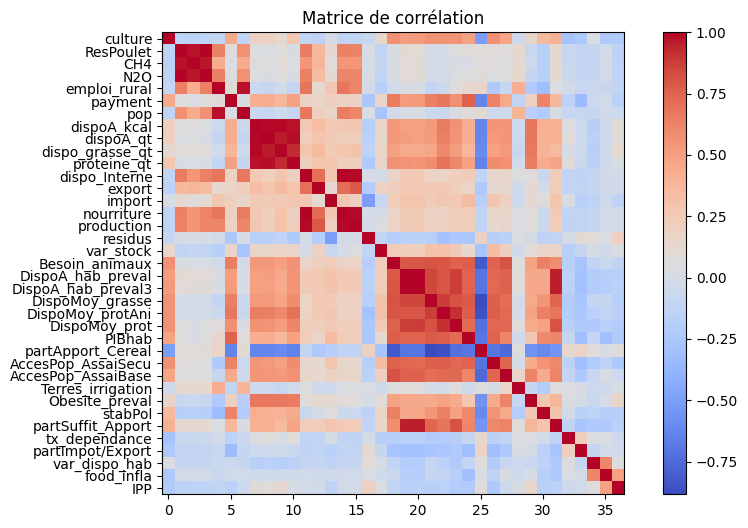

In [94]:
# Matrice de corrélation
plt.subplots(1, 1, figsize = (10, 6))
plt.imshow(matrix_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.yticks(range(len(matrix_corr)),matrix_corr.columns)
plt.title("Matrice de corrélation")

plt.savefig("matrix_corr_original.png")
plt.show()

# Beaucoup de valeurs corrélées fortement

### Matrice de corrélation avec les données manquantes corrigées

In [95]:
# Remplacer les valeurs nulles par les valeurs centrales
nomcols = comp_nan_num.columns.to_list()
remplacer_na(comp_nan_num, nomcols)


In [96]:
# Corrélation avec les données manquantes corrigées
matrix_corr = comp_nan_num.corr()

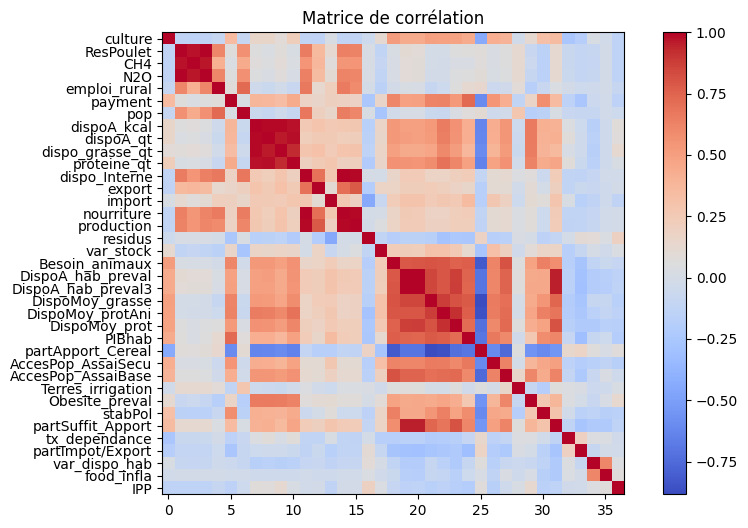

In [97]:
# Matrice de corrélation
plt.subplots(1, 1, figsize = (10, 6))
plt.imshow(matrix_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
#plt.xticks(range(len(matrix_corr)), matrix_corr.columns, rotation=45)
plt.yticks(range(len(matrix_corr)),matrix_corr.columns)

plt.title("Matrice de corrélation")
plt.show() # Pas de changement évident

### Matrice de corrélation avec les variables sélectionnées

**Choix de variables finales :**

Ces variables sont peu corrélées linéairement d'après la matrice de corrélation : 
- culture, CH4, emploi_rural, payment, pop, dispoA_qt, export, var_stock, PIBhab, Terres_irrigation, Obesite_preval, stabPol, partSuffit_Apport,	tx_dependance,	var_dispo_hab,	food_infla,	IPP

In [98]:
# Corrélation des variables sélectionnées
tab_num = comp_nan_num.drop(columns = ["N2O", "ResPoulet", "dispoA_kcal", "dispo_grasse_qt", "proteine_qt", 'Besoin_animaux', "nourriture",
                                    'DispoA_hab_preval', "production", "dispo_Interne", "AccesPop_AssaiSecu", "AccesPop_AssaiBase",
                                    'DispoA_hab_preval3', 'DispoMoy_grasse', 'DispoMoy_protAni', "import", "partApport_Cereal", 
                                    'DispoMoy_prot', 'partImpot/Export', "residus"])

matrix_corr = tab_num.corr() 

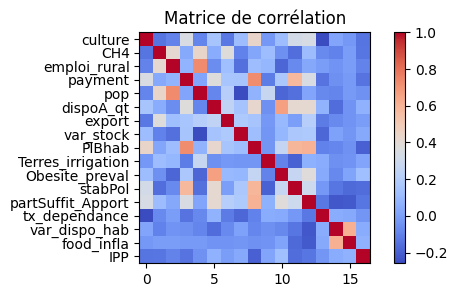

In [99]:
# Matrice de corrélation
plt.subplots(figsize=(6, 3))
plt.imshow(matrix_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.yticks(range(len(matrix_corr)),matrix_corr.columns)

plt.title("Matrice de corrélation")
plt.show()

# La corrélation linéaire entre les variables baisse fortement

<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">2 - Distribution des variables sélectionnées </h3>
</div>

On peut observer ici les statistiques des valeurs sélectionnées ainsi que leurs distributions. 
Afin de réaliser les ajustements des valeurs trop extrêmes et de neutraliser les valeurs trop aberrantes.
    

In [100]:
tab_num.describe()

,culture,CH4,emploi_rural,payment,pop,dispoA_qt,export,var_stock,PIBhab,Terres_irrigation,Obesite_preval,stabPol,partSuffit_Apport,tx_dependance,var_dispo_hab,food_infla,IPP
count,139.000000,139.000000,139.000000,139.000000,1.390000e+02,139.000000,139.000000,139.000000,139.000000,139.000000,139.00000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000
mean,1.872295,2.124232,8374.039457,45.751617,4.906557e+04,19.755755,137.179487,10.789855,24291.982609,3.612687,19.80146,-0.085693,123.266187,22.580576,40.280576,8.328340,103.471197
std,1.190221,6.711858,28395.327516,23.920099,1.691631e+05,15.452531,491.890182,40.339044,22811.082635,5.737171,9.86534,0.846850,13.679338,68.978404,31.939941,40.945364,14.130362
min,0.000000,0.000000,6.970000,7.700673,7.145800e+01,0.450000,0.000000,-119.000000,1520.000000,0.000000,1.30000,-2.790000,91.000000,-290.300000,10.000000,-3.718112,73.060000
25%,0.958942,0.096550,1006.645000,27.286375,4.144813e+03,6.420000,0.000000,0.000000,6075.100000,0.400000,11.85000,-0.635000,115.000000,4.250000,23.000000,1.018225,96.790000
50%,1.872295,0.399800,4932.000000,44.664759,1.051310e+04,18.200000,7.000000,0.000000,16128.600000,1.300000,20.20000,-0.060000,123.000000,39.000000,32.000000,3.016109,103.250000
75%,2.399044,1.361950,8374.039457,59.250031,3.434122e+04,28.130000,137.179487,10.394928,34698.650000,4.200000,26.25000,0.580000,133.000000,68.000000,46.000000,6.847455,106.450000
max,7.159512,64.446700,328500.000000,100.000000,1.421022e+06,72.310000,4223.000000,225.000000,132170.000000,42.500000,59.10000,1.560000,162.000000,100.000000,262.000000,480.863389,156.600000


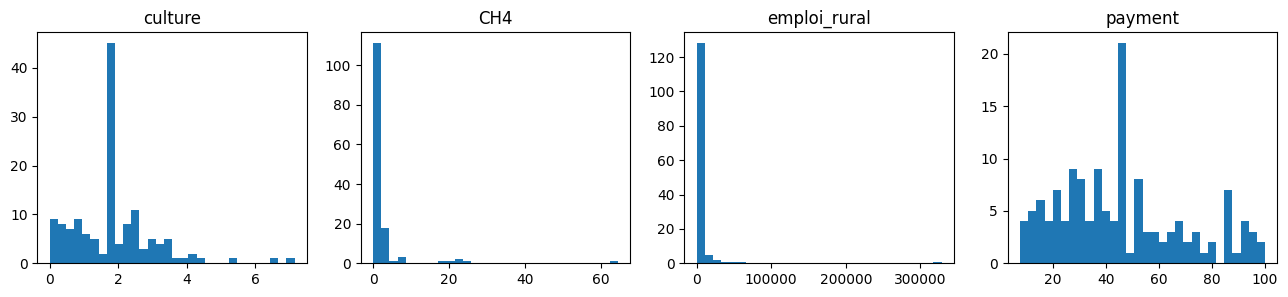

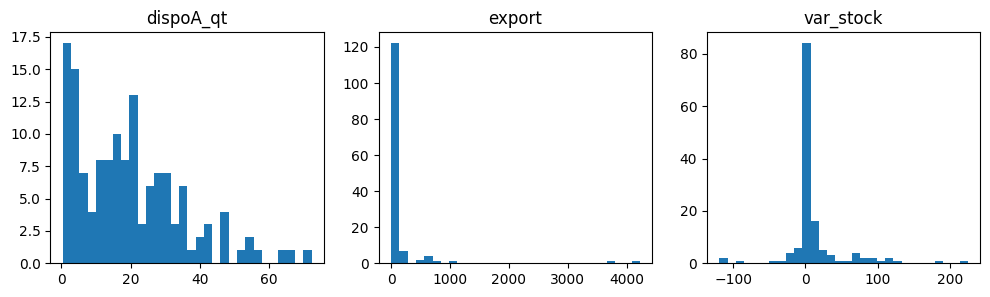

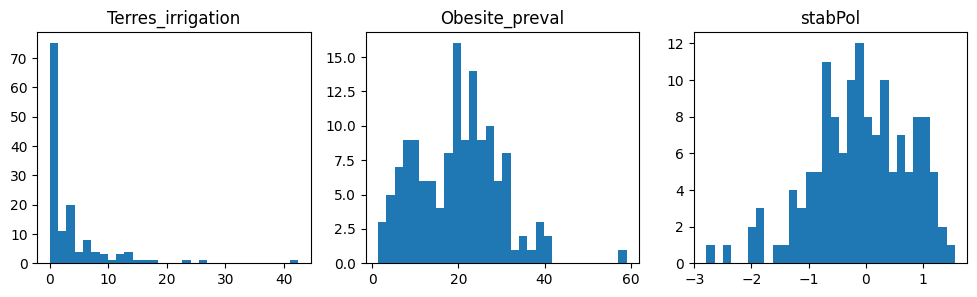

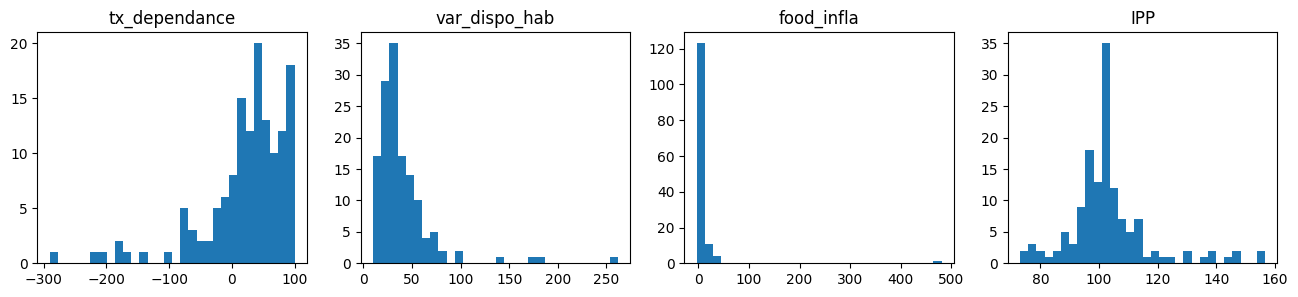

In [101]:
hist_data(tab_num, tab_num.columns[0:4].to_list())
hist_data(tab_num, tab_num.columns[5:8].to_list())
hist_data(tab_num, tab_num.columns[9:12].to_list())
hist_data(tab_num, tab_num.columns[13:17].to_list())

# CH4, emploi_rural, pop, export, PIBhab, Terres_irrigation, var_dispo_hab sont très assymétriques et positives, on peut les appliquer la transformation logarithmiques (la fonction log ne s'applique pas pour tx_dépendance)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Ecriture des données </h2>
</div>

On reprend depuis le jeu de données précédent et on déroule les processus au propre. 
- nettoyage des valeurs manquantes;
- ajustement des valeurs extrêmes, si possible, à travers la logarithme
- neutraliser les valeurs aberrantes

In [102]:
complet = pays_comp_nan[['culture', 'CH4', 'emploi_rural', 'payment', 'pop', 'dispoA_qt',
       'export', 'var_stock', 'PIBhab', 'Terres_irrigation', 'Obesite_preval',
       'stabPol', 'partSuffit_Apport', 'tx_dependance', 'var_dispo_hab',
       'food_infla', 'IPP']]

complet.info() # choix des variables peu corrélées

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, Bénin to Ukraine
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culture            98 non-null     float64
 1   CH4                139 non-null    float64
 2   emploi_rural       92 non-null     float64
 3   payment            122 non-null    float64
 4   pop                138 non-null    float64
 5   dispoA_qt          139 non-null    float64
 6   export             117 non-null    float64
 7   var_stock          138 non-null    float64
 8   PIBhab             138 non-null    float64
 9   Terres_irrigation  134 non-null    float64
 10  Obesite_preval     137 non-null    float64
 11  stabPol            137 non-null    float64
 12  partSuffit_Apport  139 non-null    float64
 13  tx_dependance      135 non-null    float64
 14  var_dispo_hab      139 non-null    float64
 15  food_infla         138 non-null    float64
 16  IPP                117 

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">2 - Données finales </h2>
</div>

### Remplir les valeurs manquantes

In [103]:
# Valeurs nulles remplacées par les valeurs centrales
nomcols = complet.columns.to_list()
remplacer_na(complet, nomcols)


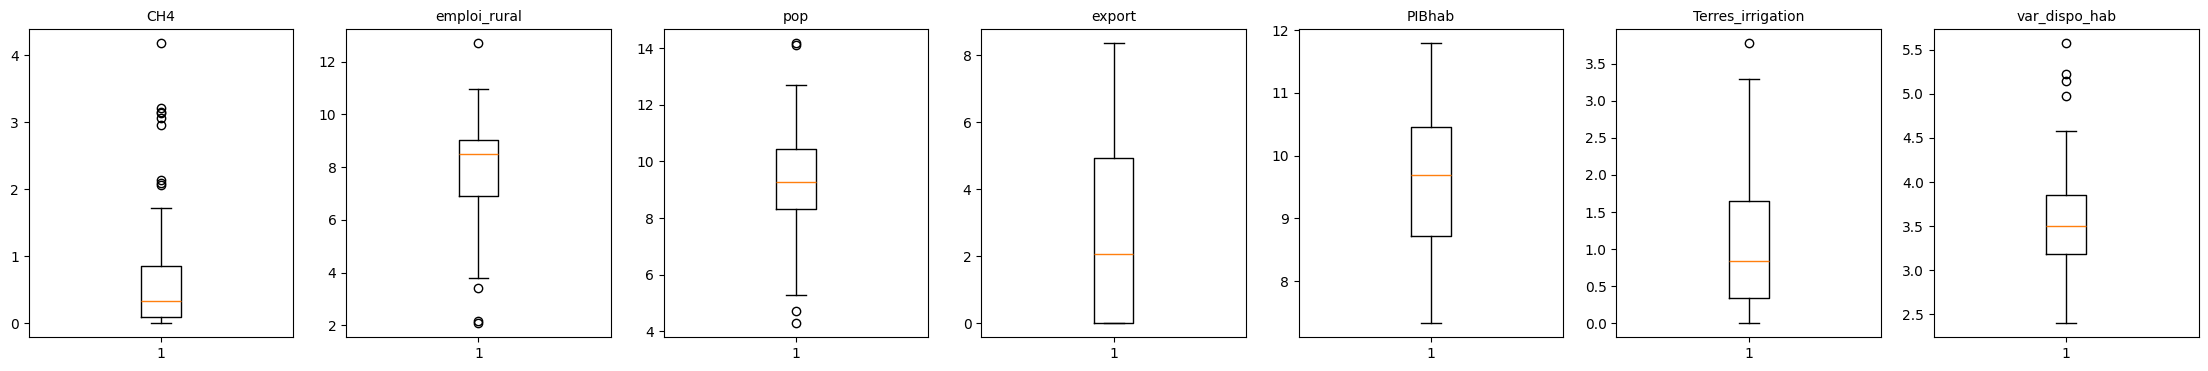

In [104]:
# En logarithmes pour les variables qui sont trop assymétriques d'après l'observation des distributions
# CH4, emploi_rural, pop, export, PIBhab, Terres_irrigation, var_dispo_hab
cols = ['CH4', 'emploi_rural', 'pop', 'export', 'PIBhab', 'Terres_irrigation', 'var_dispo_hab']
for col in cols:
    complet.loc[:, col] = np.log1p(complet[col])

plot_data(complet, cols)

### Matrice de corrélation après la transformation logarithmique

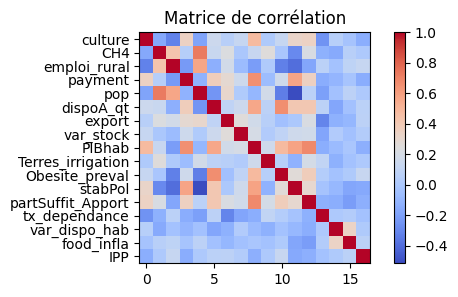

In [105]:
matrix_corr = complet.corr()

# Matrice de corrélation après la transformation logarithme
plt.subplots(figsize=(6, 3))
plt.imshow(matrix_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.yticks(range(len(matrix_corr)),matrix_corr.columns)

plt.title("Matrice de corrélation")
plt.show()

### Neutraliser les données aberrantes

In [106]:
# Valeurs outliers à retraiter
cols = ['culture', 'CH4', 'emploi_rural', 'payment', 'pop', 'dispoA_qt',
       'export', 'var_stock', 'PIBhab', 'Terres_irrigation', 'Obesite_preval',
       'stabPol', 'partSuffit_Apport', 'tx_dependance', 'var_dispo_hab',
       'food_infla', 'IPP']            
complet1 = outliers_median(complet, cols)

#["food_infla", "var_stock", "CH4", "IPP"] possède des valeurs aberrantes à corriger. 
# il n'existe pas beaucou au max. 5.
# Ces valeurs aberrantes sont peu nombreux, mais explicables comme l'inflation alimentaire à Venezuela (à 500%)

culture : Le nombre de outliers est 0. Sa médiane est 1.87
CH4 : Le nombre de outliers est 1. Sa médiane est 0.34
emploi_rural : Le nombre de outliers est 0. Sa médiane est 8.5
payment : Le nombre de outliers est 0. Sa médiane est 44.66
pop : Le nombre de outliers est 0. Sa médiane est 9.26
dispoA_qt : Le nombre de outliers est 0. Sa médiane est 18.2
export : Le nombre de outliers est 0. Sa médiane est 2.08
var_stock : Le nombre de outliers est 4. Sa médiane est 0.0
PIBhab : Le nombre de outliers est 0. Sa médiane est 9.69
Terres_irrigation : Le nombre de outliers est 0. Sa médiane est 0.83
Obesite_preval : Le nombre de outliers est 0. Sa médiane est 20.2
stabPol : Le nombre de outliers est 0. Sa médiane est -0.06
partSuffit_Apport : Le nombre de outliers est 0. Sa médiane est 123.0
tx_dependance : Le nombre de outliers est 0. Sa médiane est 39.0
var_dispo_hab : Le nombre de outliers est 0. Sa médiane est 3.5
food_infla : Le nombre de outliers est 4. Sa médiane est 3.02
IPP : Le nombre

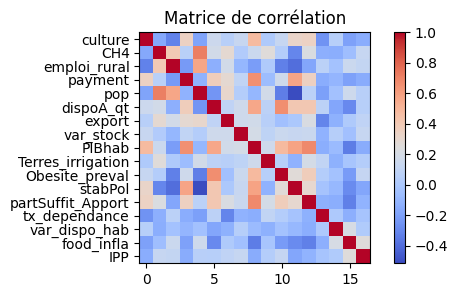

In [107]:
matrix_corr = complet1.corr()

# Matrice de corrélation après la transformation logarithme
plt.subplots(figsize=(6, 3))
plt.imshow(matrix_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.yticks(range(len(matrix_corr)),matrix_corr.columns)

plt.title("Matrice de corrélation")
plt.savefig("Matrice_correlation_finale.png")
plt.show() 

# Pas beaucoup de changement au niveau de la matrice

In [108]:
print("Voici l'information de données finales :")
complet1.info()

Voici l'information de données finales :
<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, Bénin to Ukraine
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culture            139 non-null    float64
 1   CH4                139 non-null    float64
 2   emploi_rural       139 non-null    float64
 3   payment            139 non-null    float64
 4   pop                139 non-null    float64
 5   dispoA_qt          139 non-null    float64
 6   export             139 non-null    float64
 7   var_stock          139 non-null    float64
 8   PIBhab             139 non-null    float64
 9   Terres_irrigation  139 non-null    float64
 10  Obesite_preval     139 non-null    float64
 11  stabPol            139 non-null    float64
 12  partSuffit_Apport  139 non-null    float64
 13  tx_dependance      139 non-null    float64
 14  var_dispo_hab      139 non-null    float64
 15  food_infla         139 non-nul

Voici un tableau descriptif de ce jeu de données :

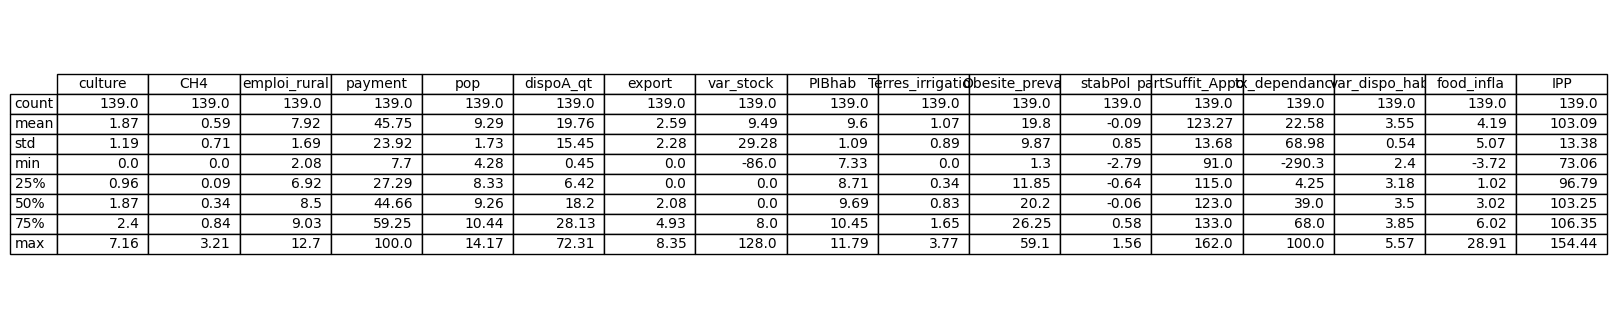

In [127]:
tab = complet1.describe().round(2)

fig, ax = plt.subplots(figsize=(20, 4))
ax.axis('off')

table = ax.table(
    cellText=tab.values,
    colLabels=tab.columns,
    rowLabels=tab.index,
    loc='center'
)

table.scale(1, 1.2)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.savefig("describe.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Ecriture de données finales
complet1.to_csv("complet_final.csv")

# Fin notebook